Generating problem instance...
Selecting optimal facility locations...
Running UAV path optimization...

Optimization Results:
Facilities opened: 10/10
Total demand points: 1000
Demand points served: 1000 (100.0%)
Total routes generated: 43
Drone utilization: 43/1000 (4.3%)
Average points per route: 23.3

Displaying facility clusters...


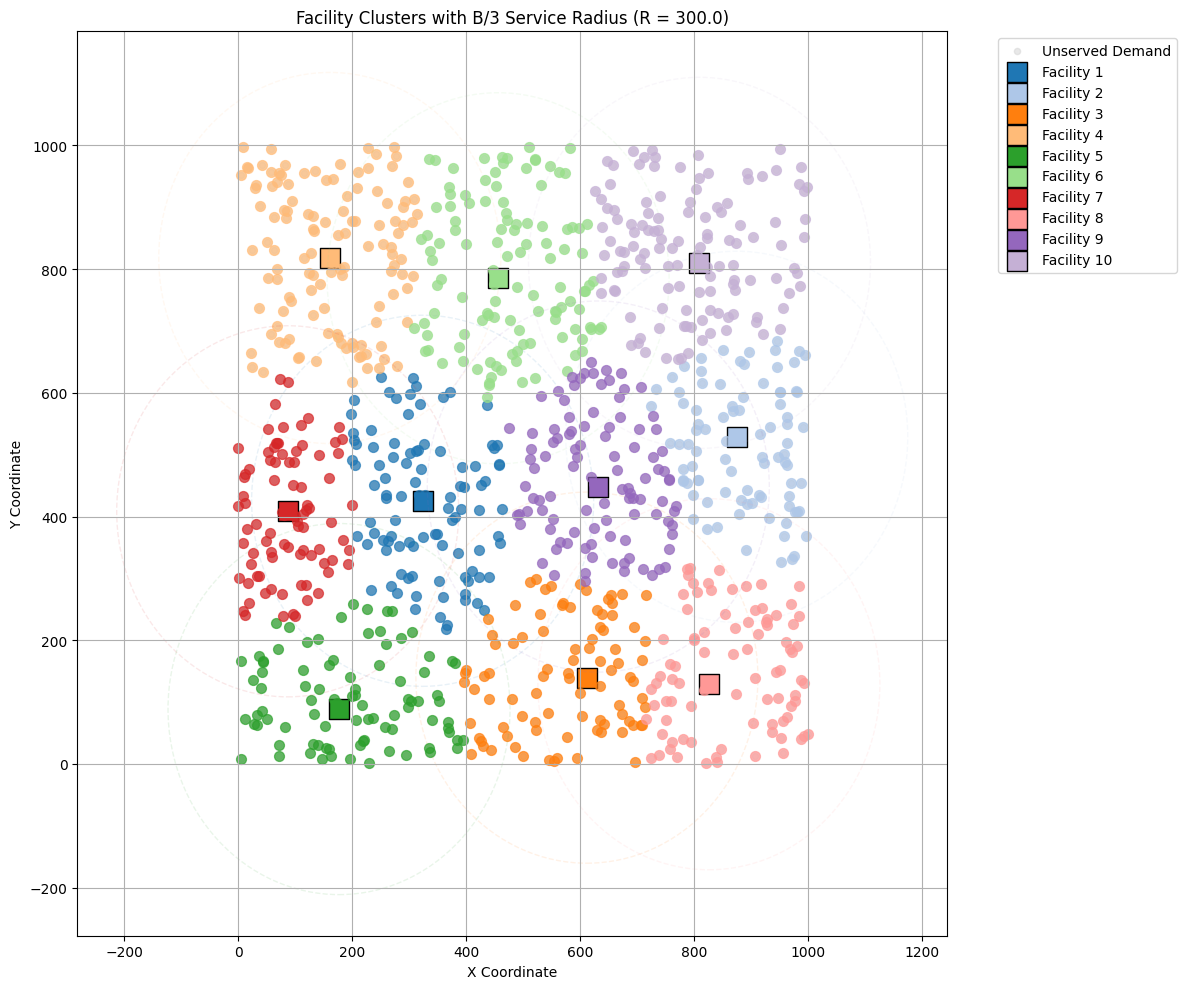

Displaying complete route visualization...


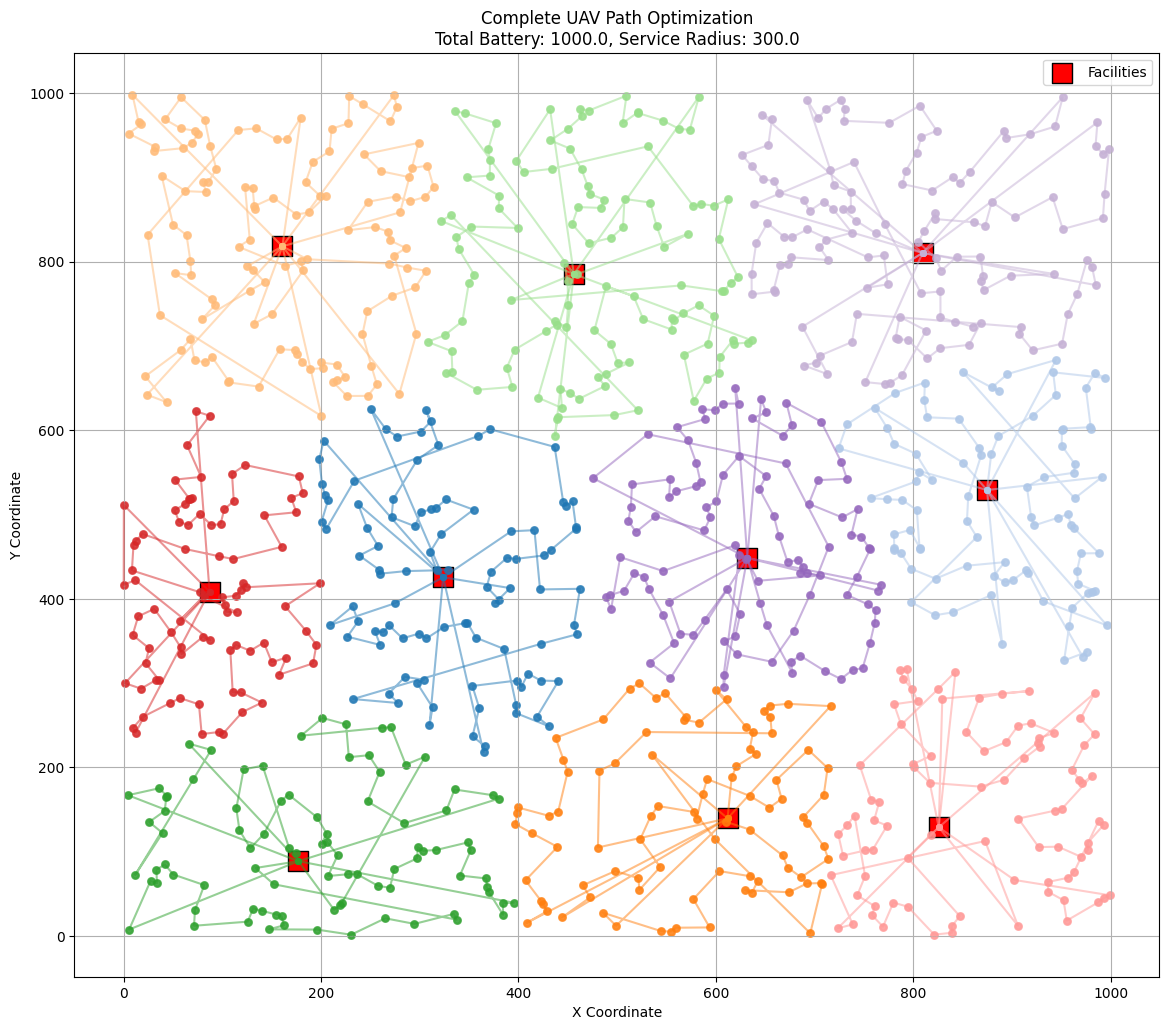


Optimization complete!


In [3]:
import numpy as np
import math
from typing import List, Tuple, Dict, Set
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.cluster import KMeans
from IPython.display import HTML
import random

class UAVPathOptimizer:
    """
    UAV Path Optimizer with B/3 strategy and enhanced visualization
    """
    
    def __init__(self, facilities, demand_points, B, battery_buffer=0.9):
        self.facilities = facilities
        self.demand_points = demand_points
        self.B = B
        self.R = (B * battery_buffer) / 3
        self.clusters = self._cluster_demand_points()
        self.colors = plt.cm.tab20.colors  # Color palette for visualization

    def _distance(self, p1, p2):
        return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    def _cluster_demand_points(self):
        """Assign demand points to nearest facility within B/3 radius"""
        clusters = {fac: [] for fac in self.facilities}
        for point in self.demand_points:
            nearest_fac = min(self.facilities, key=lambda f: self._distance(f, point))
            if self._distance(nearest_fac, point) <= self.R:
                clusters[nearest_fac].append(point)
        return clusters

    def optimize_routes(self):
        """Generate optimized routes with B/3 constraints"""
        routes = {}
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            unserved = set(points)
            facility_routes = []
            
            while unserved:
                route = [fac]
                remaining_battery = self.B
                
                # Furthest-first initialization
                if not unserved:
                    break
                farthest = max(unserved, key=lambda p: self._distance(fac, p))
                dist = self._distance(fac, farthest)
                
                if dist > remaining_battery / 2:
                    break  # Can't reach and return
                
                route.append(farthest)
                unserved.remove(farthest)
                remaining_battery -= dist
                
                # Nearest-neighbor greedy addition
                while unserved and remaining_battery > 0:
                    current_pos = route[-1]
                    next_point = None
                    min_dist = float('inf')
                    
                    for p in unserved:
                        dist = self._distance(current_pos, p)
                        return_dist = self._distance(p, fac)
                        if dist + return_dist <= remaining_battery and dist < min_dist:
                            min_dist = dist
                            next_point = p
                            
                    if next_point is None:
                        break
                        
                    route.append(next_point)
                    unserved.remove(next_point)
                    remaining_battery -= min_dist
                
                # Return to facility
                route.append(fac)
                facility_routes.append(route)
            
            routes[fac] = facility_routes
            
        return routes

    def visualize_clusters(self):
        """Visualize facility clusters with service radius"""
        plt.figure(figsize=(12, 10))
        
        # Plot all demand points (gray)
        all_x, all_y = zip(*self.demand_points)
        plt.scatter(all_x, all_y, c='lightgray', s=20, alpha=0.5, label='Unserved Demand')
        
        # Plot facilities and their clusters
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            fac_x, fac_y = fac
            
            # Draw service radius
            circle = plt.Circle(fac, self.R, color=self.colors[fac_idx % 20], 
                              alpha=0.1, linestyle='--', fill=False)
            plt.gca().add_patch(circle)
            
            # Plot facility
            plt.scatter(fac_x, fac_y, c=[self.colors[fac_idx % 20]], 
                       s=200, marker='s', edgecolor='k', label=f'Facility {fac_idx+1}')
            
            # Plot served points
            if points:
                cluster_x, cluster_y = zip(*points)
                plt.scatter(cluster_x, cluster_y, c=[self.colors[fac_idx % 20]], 
                           s=50, alpha=0.7)
        
        plt.title(f"Facility Clusters with B/3 Service Radius (R = {self.R:.1f})")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def animate_routes(self, routes, facility_idx=0, speed=100):
        """Animate drone routes for a specific facility"""
        if facility_idx >= len(self.facilities):
            print("Invalid facility index")
            return
        
        fac = list(self.clusters.keys())[facility_idx]
        fac_routes = routes.get(fac, [])
        
        if not fac_routes:
            print("No routes for this facility")
            return
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Setup plot
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_title(f"Drone Routes for Facility {facility_idx+1}\n(Battery: {self.B}, Radius: {self.R:.1f})")
        ax.grid(True)
        
        # Plot facility and demand points
        fac_x, fac_y = fac
        ax.scatter(fac_x, fac_y, c='red', s=200, marker='s', label='Facility')
        
        # Plot all demand points
        demand_x, demand_y = zip(*self.clusters[fac])
        ax.scatter(demand_x, demand_y, c='blue', s=50, alpha=0.5, label='Demand Points')
        
        # Initialize route lines and drones
        lines = []
        drones = []
        for _ in fac_routes:
            line, = ax.plot([], [], 'o-', lw=2, alpha=0.7)
            lines.append(line)
            drone, = ax.plot([], [], 'ko', ms=10)
            drones.append(drone)
        
        def init():
            for line, drone in zip(lines, drones):
                line.set_data([], [])
                drone.set_data([], [])
            return lines + drones
        
        def animate(i):
            for route_idx, route in enumerate(fac_routes):
                if i < len(route):
                    x, y = zip(*route[:i+1])
                    lines[route_idx].set_data(x, y)
                    drones[route_idx].set_data(route[i][0], route[i][1])
            return lines + drones
        
        ani = FuncAnimation(fig, animate, frames=max(len(r) for r in fac_routes),
                           init_func=init, interval=speed, blit=True)
        plt.legend()
        plt.close()
        return HTML(ani.to_jshtml())

    def visualize_all_routes(self, routes):
        """Static visualization of all routes"""
        plt.figure(figsize=(14, 12))
        
        # Plot facilities
        fac_x, fac_y = zip(*self.facilities)
        plt.scatter(fac_x, fac_y, c='red', s=200, marker='s', edgecolor='k', label='Facilities')
        
        # Plot demand points
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            if points:
                x, y = zip(*points)
                plt.scatter(x, y, c=[self.colors[fac_idx % 20]], s=30, alpha=0.7)
        
        # Plot routes
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            for route in fac_routes:
                x, y = zip(*route)
                plt.plot(x, y, 'o-', c=self.colors[fac_idx % 20], 
                        alpha=0.5, lw=1.5, ms=4)
        
        plt.title(f"Complete UAV Path Optimization\nTotal Battery: {self.B}, Service Radius: {self.R:.1f}")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.grid(True)
        plt.legend()
        plt.show()

if __name__ == "__main__":
    import numpy as np
    
    # ======================
    # USER-CONFIGURABLE PARAMETERS
    # ======================
    # Edit these values directly in the script before running
    
    # Problem Parameters
    p = 10               # Maximum number of facilities to open (integer)
    K = 1000             # Total drones available (integer)
    U = 200.0            # Facility capacity (float)
    B = 1000.0            # Drone battery capacity (float)
    battery_buffer = 0.9 # Battery safety margin (0-1, float)
    
    # Data Generation Parameters
    num_facility_locations = 600  # Potential locations to choose from (integer)
    num_demand_points = 1000     # Total demand points (integer)
    random_seed = 42              # For reproducible results (integer)
    area_size = 1000.0             # Size of operational area in km (float)
    
    # Visualization Options
    show_cluster_plot = True      # Show facility clusters visualization
    show_route_plot = True        # Show complete routes visualization
    
    # ======================
    # DATA GENERATION
    # ======================
    np.random.seed(random_seed)
    
    print("Generating problem instance...")
    facility_locations = [(np.random.uniform(0, area_size), 
                         np.random.uniform(0, area_size)) 
                         for _ in range(num_facility_locations)]
    
    demand_points = [(np.random.uniform(0, area_size), 
                    np.random.uniform(0, area_size)) 
                    for _ in range(num_demand_points)]
    
    # Calculate distances (battery consumption)
    def euclidean_distance(a, b):
        return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    
    # ======================
    # FACILITY SELECTION
    # ======================
    print("Selecting optimal facility locations...")
    kmeans = KMeans(n_clusters=p, random_state=random_seed)
    coords = np.array(demand_points)
    kmeans.fit(coords)
    
    selected_facilities = []
    for center in kmeans.cluster_centers_:
        nearest_fac = min(facility_locations, 
                         key=lambda f: euclidean_distance(f, tuple(center)))
        selected_facilities.append(nearest_fac)
    
    # ======================
    # RUN OPTIMIZATION
    # ======================
    print("Running UAV path optimization...")
    optimizer = UAVPathOptimizer(
        facilities=selected_facilities,
        demand_points=demand_points,
        B=B,
        battery_buffer=battery_buffer
    )
    
    routes = optimizer.optimize_routes()
    
    # ======================
    # RESULTS
    # ======================
    print("\nOptimization Results:")
    print("====================")
    
    total_routes = sum(len(r) for r in routes.values())
    served = sum(len(route)-2 for fac_routes in routes.values() for route in fac_routes)
    
    print(f"Facilities opened: {len(selected_facilities)}/{p}")
    print(f"Total demand points: {num_demand_points}")
    print(f"Demand points served: {served} ({served/num_demand_points:.1%})")
    print(f"Total routes generated: {total_routes}")
    print(f"Drone utilization: {total_routes}/{K} ({total_routes/K:.1%})")
    print(f"Average points per route: {served/total_routes:.1f}")
    
    # ======================
    # VISUALIZATION
    # ======================
    if show_cluster_plot:
        print("\nDisplaying facility clusters...")
        optimizer.visualize_clusters()
    
    if show_route_plot:
        print("Displaying complete route visualization...")
        optimizer.visualize_all_routes(routes)
    
    print("\nOptimization complete!")


Generating individual cluster diagrams...


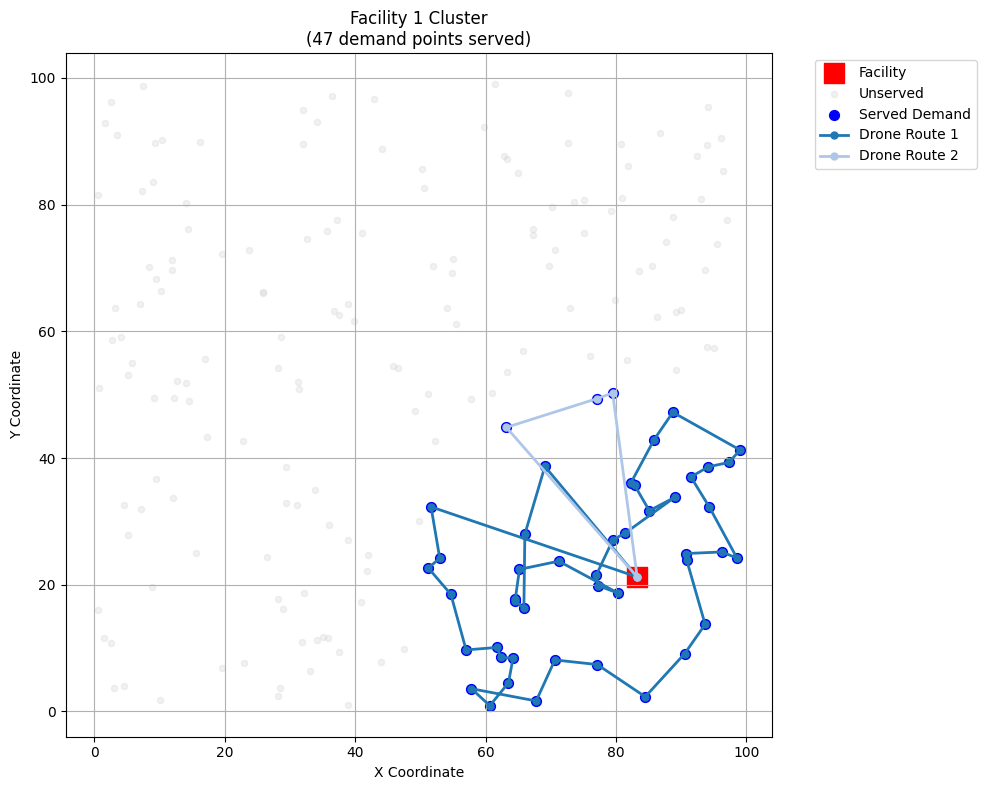

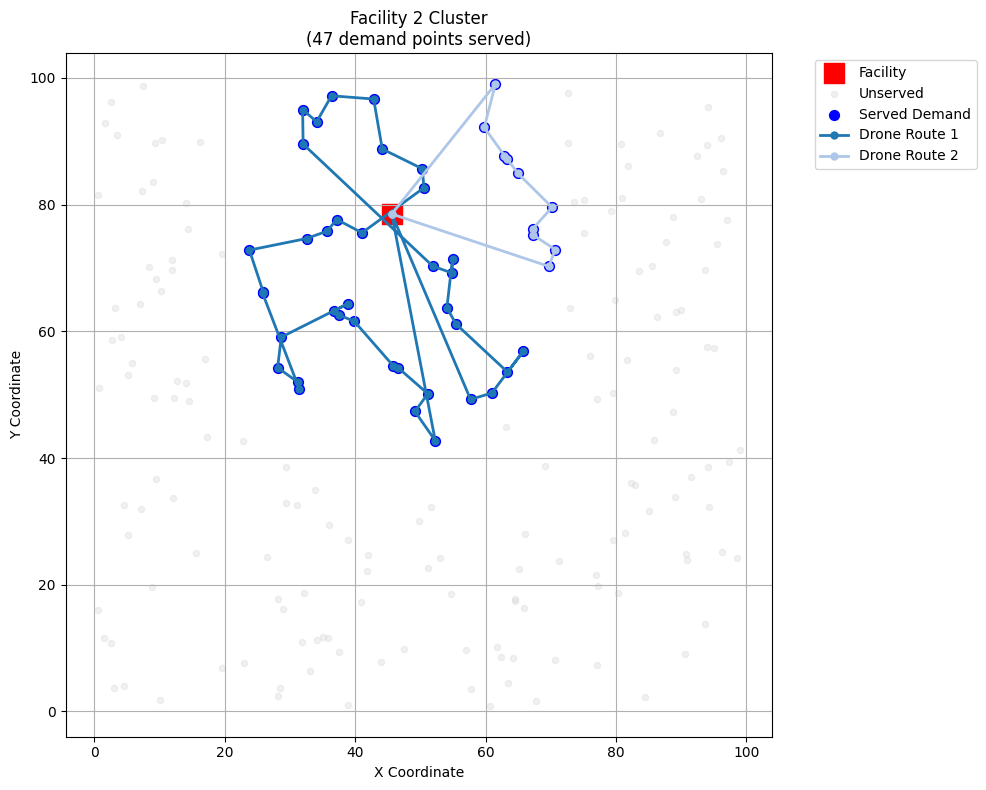

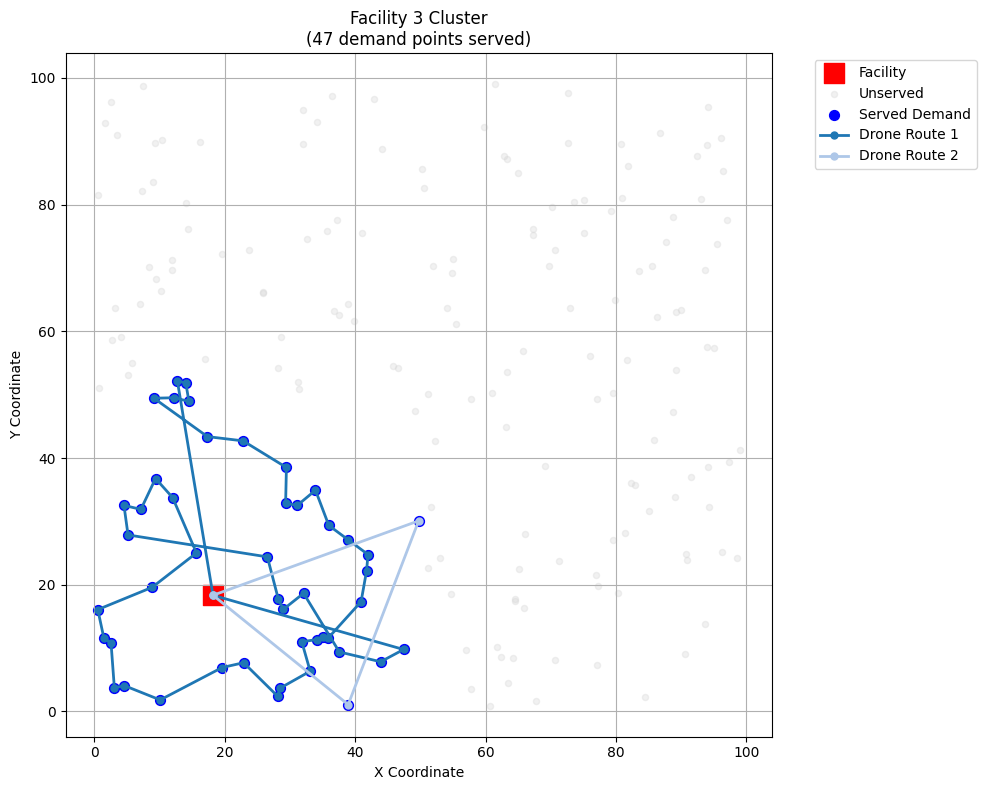

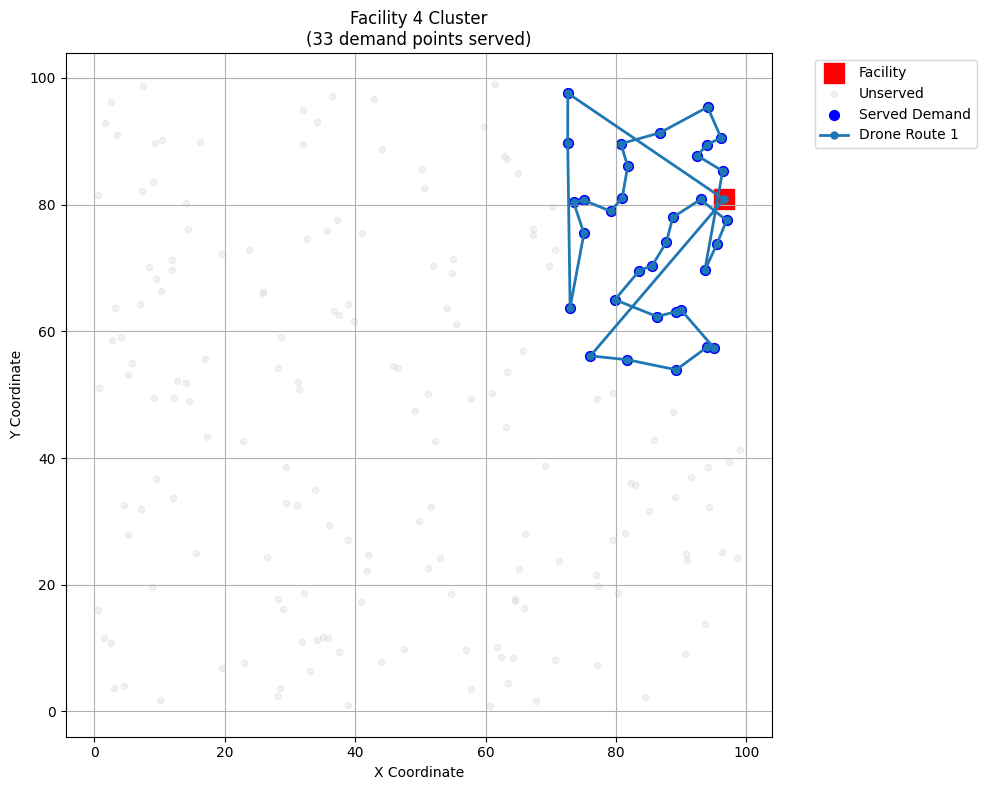

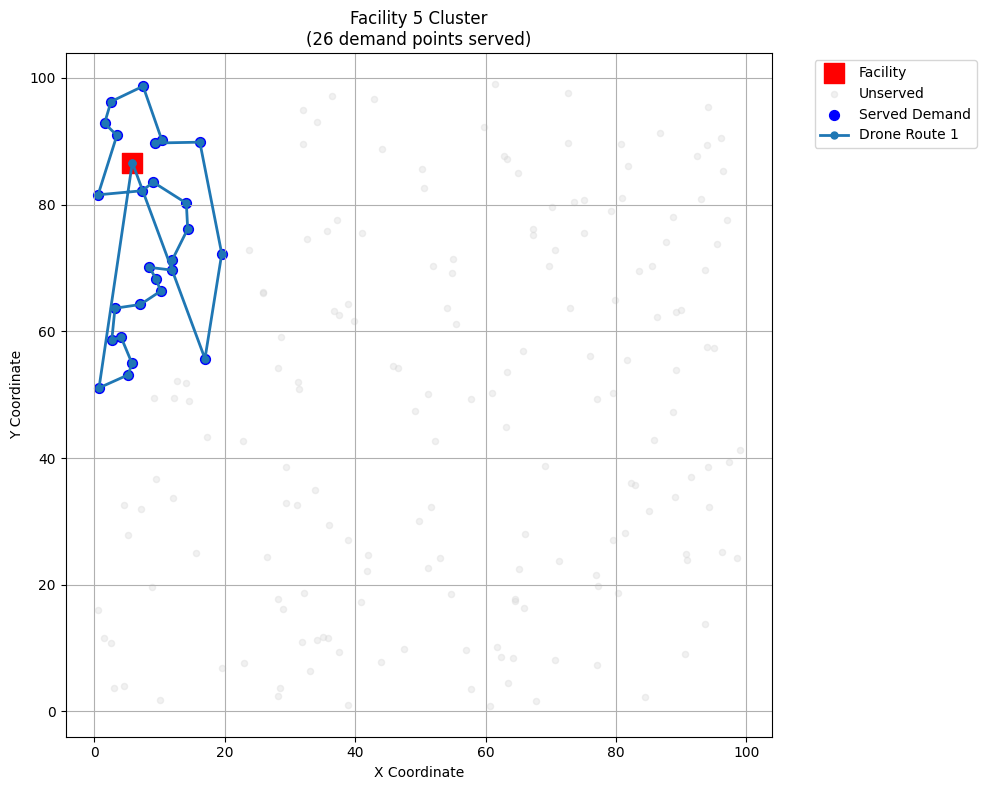


Generating complete solution diagram...


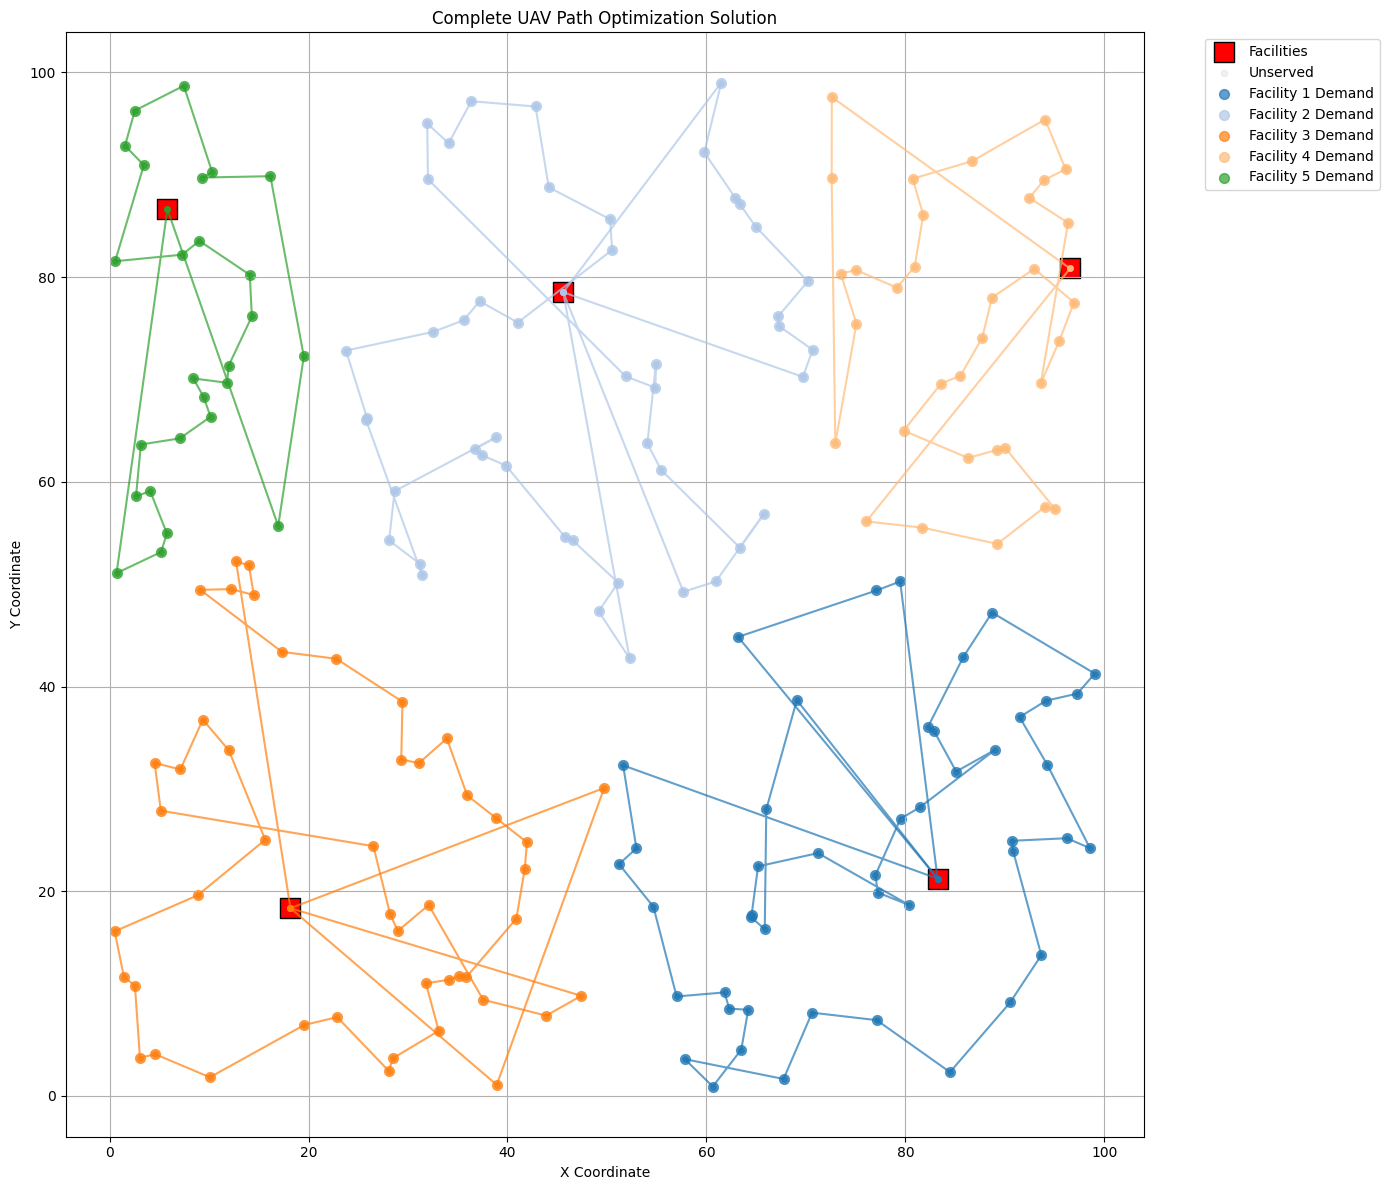


Results:
Facilities: 5
Demand points: 200
Served points: 200 (100.0%)
Total routes: 8
Drone utilization: 8/20


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import math
from typing import List, Tuple, Dict

class UAVPathOptimizer:
    def __init__(self, facilities, demand_points, B, battery_buffer=0.9):
        self.facilities = facilities
        self.demand_points = demand_points
        self.B = B
        self.R = (B * battery_buffer) / 3
        self.clusters = self._cluster_demand_points()
        self.colors = plt.cm.tab20.colors  # Color palette for visualization

    def _distance(self, p1, p2):
        return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    def _cluster_demand_points(self):
        clusters = {fac: [] for fac in self.facilities}
        for point in self.demand_points:
            nearest_fac = min(self.facilities, key=lambda f: self._distance(f, point))
            if self._distance(nearest_fac, point) <= self.R:
                clusters[nearest_fac].append(point)
        return clusters

    def optimize_routes(self):
        routes = {}
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            unserved = set(points)
            facility_routes = []
            
            while unserved:
                route = [fac]
                remaining_battery = self.B
                
                farthest = max(unserved, key=lambda p: self._distance(fac, p))
                dist = self._distance(fac, farthest)
                
                if dist > remaining_battery / 2:
                    break
                
                route.append(farthest)
                unserved.remove(farthest)
                remaining_battery -= dist
                
                while unserved and remaining_battery > 0:
                    current_pos = route[-1]
                    next_point = None
                    min_dist = float('inf')
                    
                    for p in unserved:
                        dist = self._distance(current_pos, p)
                        return_dist = self._distance(p, fac)
                        if dist + return_dist <= remaining_battery and dist < min_dist:
                            min_dist = dist
                            next_point = p
                            
                    if next_point is None:
                        break
                        
                    route.append(next_point)
                    unserved.remove(next_point)
                    remaining_battery -= min_dist
                
                route.append(fac)
                facility_routes.append(route)
            
            routes[fac] = facility_routes
            
        return routes

    def plot_individual_clusters(self, routes):
        """Generate separate cluster plots for each facility"""
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            plt.figure(figsize=(10, 8))
            
            # Plot facility
            plt.scatter(fac[0], fac[1], c='red', s=200, marker='s', label='Facility')
            
            # Plot all demand points (served and unserved)
            all_x, all_y = zip(*self.demand_points)
            plt.scatter(all_x, all_y, c='lightgray', s=20, alpha=0.3, label='Unserved')
            
            # Plot served points
            served = set()
            for route in fac_routes:
                served.update(route[1:-1])  # Exclude facility at start/end
            
            if served:
                served_x, served_y = zip(*served)
                plt.scatter(served_x, served_y, c='blue', s=50, label='Served Demand')
            
            # Plot routes with different colors
            for route_idx, route in enumerate(fac_routes):
                route_x, route_y = zip(*route)
                plt.plot(route_x, route_y, 'o-', 
                         color=self.colors[route_idx % 20],
                         linewidth=2,
                         markersize=5,
                         label=f'Drone Route {route_idx+1}')
            
            plt.title(f'Facility {fac_idx+1} Cluster\n({len(served)} demand points served)')
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    def plot_complete_solution(self, routes):
        """Plot all facilities and routes in one diagram"""
        plt.figure(figsize=(14, 12))
        
        # Plot all facilities
        fac_x, fac_y = zip(*self.facilities)
        plt.scatter(fac_x, fac_y, c='red', s=200, marker='s', edgecolor='k', label='Facilities')
        
        # Plot all demand points
        all_x, all_y = zip(*self.demand_points)
        plt.scatter(all_x, all_y, c='lightgray', s=20, alpha=0.3, label='Unserved')
        
        # Plot routes with facility-specific colors
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            # Plot served points
            served = set()
            for route in fac_routes:
                served.update(route[1:-1])
            
            if served:
                served_x, served_y = zip(*served)
                plt.scatter(served_x, served_y, 
                           color=self.colors[fac_idx % 20],
                           s=50, alpha=0.7,
                           label=f'Facility {fac_idx+1} Demand')
            
            # Plot routes
            for route_idx, route in enumerate(fac_routes):
                route_x, route_y = zip(*route)
                plt.plot(route_x, route_y, 'o-',
                         color=self.colors[fac_idx % 20],
                         linewidth=1.5,
                         markersize=4,
                         alpha=0.7)
        
        plt.title("Complete UAV Path Optimization Solution")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # Parameters (adjusted for better visualization)
    p = 5
    K = 20
    U = 200.0
    B = 300.0
    battery_buffer = 0.95
    num_facility_locations = 20
    num_demand_points = 200
    random_seed = 42
    area_size = 100.0

    # Generate data
    np.random.seed(random_seed)
    facility_locations = [(np.random.uniform(0, area_size), 
                         np.random.uniform(0, area_size)) 
                         for _ in range(num_facility_locations)]
    demand_points = [(np.random.uniform(0, area_size), 
                     np.random.uniform(0, area_size)) 
                     for _ in range(num_demand_points)]

    # Select facilities using KMeans
    kmeans = KMeans(n_clusters=p, random_state=random_seed)
    kmeans.fit(np.array(demand_points))
    selected_facilities = []
    for center in kmeans.cluster_centers_:
        nearest_fac = min(facility_locations, 
                         key=lambda f: np.linalg.norm(np.array(f)-center))
        selected_facilities.append(nearest_fac)

    # Run optimization
    optimizer = UAVPathOptimizer(selected_facilities, demand_points, B, battery_buffer)
    routes = optimizer.optimize_routes()

    # Visualization
    print("\nGenerating individual cluster diagrams...")
    optimizer.plot_individual_clusters(routes)
    
    print("\nGenerating complete solution diagram...")
    optimizer.plot_complete_solution(routes)

    # Results summary
    total_routes = sum(len(r) for r in routes.values())
    served = sum(len(route)-2 for fac_routes in routes.values() for route in fac_routes)
    print(f"\nResults:\nFacilities: {p}\nDemand points: {num_demand_points}")
    print(f"Served points: {served} ({served/num_demand_points:.1%})")
    print(f"Total routes: {total_routes}\nDrone utilization: {total_routes}/{K}")

Generating problem instance...
Selecting optimal facility locations...
Running UAV path optimization...

Optimization Results:
Facilities opened: 10/10
Total demand points: 500
Demand points served: 331 (66.2%)
Total routes generated: 47
Drone utilization: 47/100 (47.0%)
Average points per route: 7.0

Displaying facility clusters...


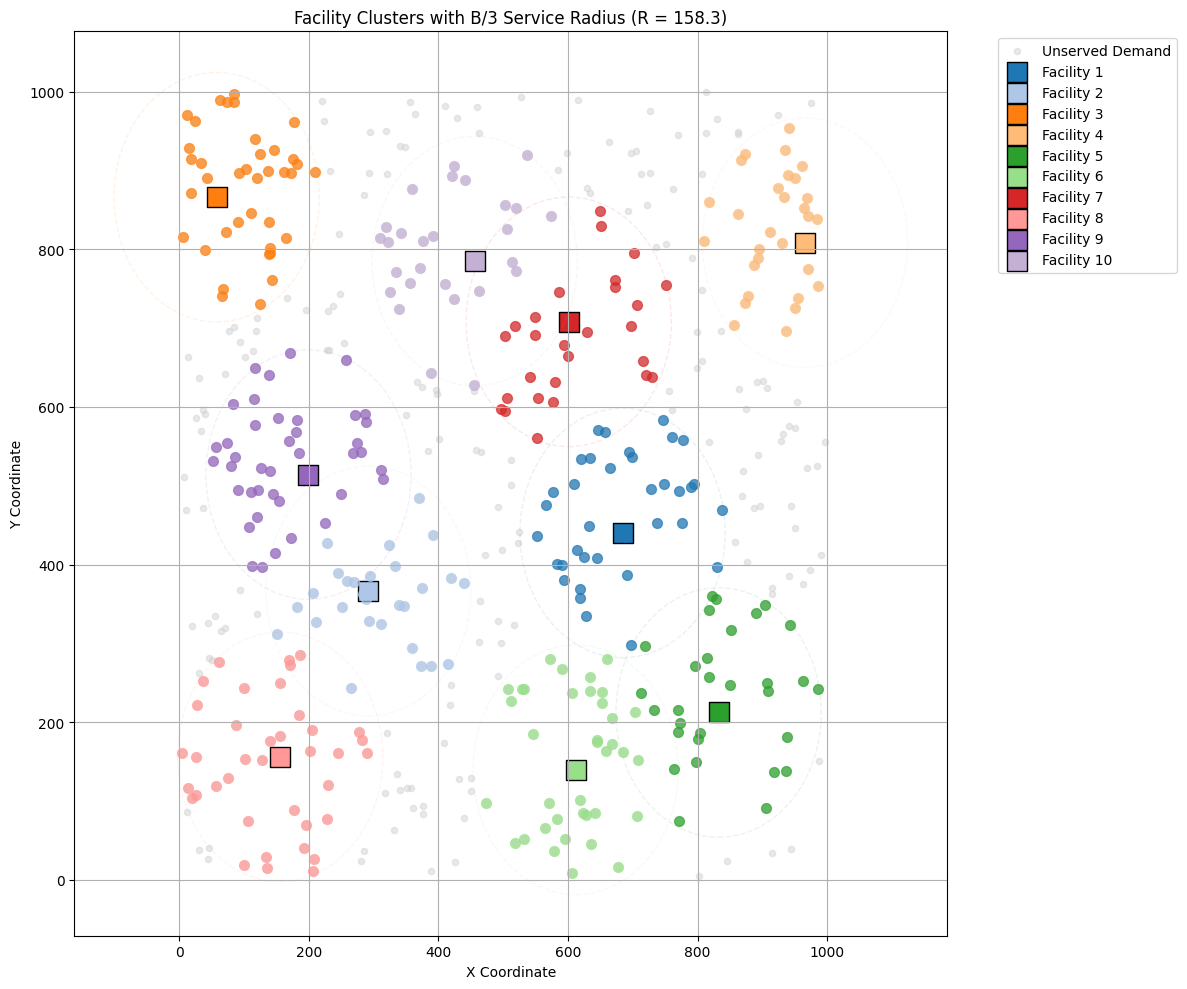


Displaying complete route visualization...


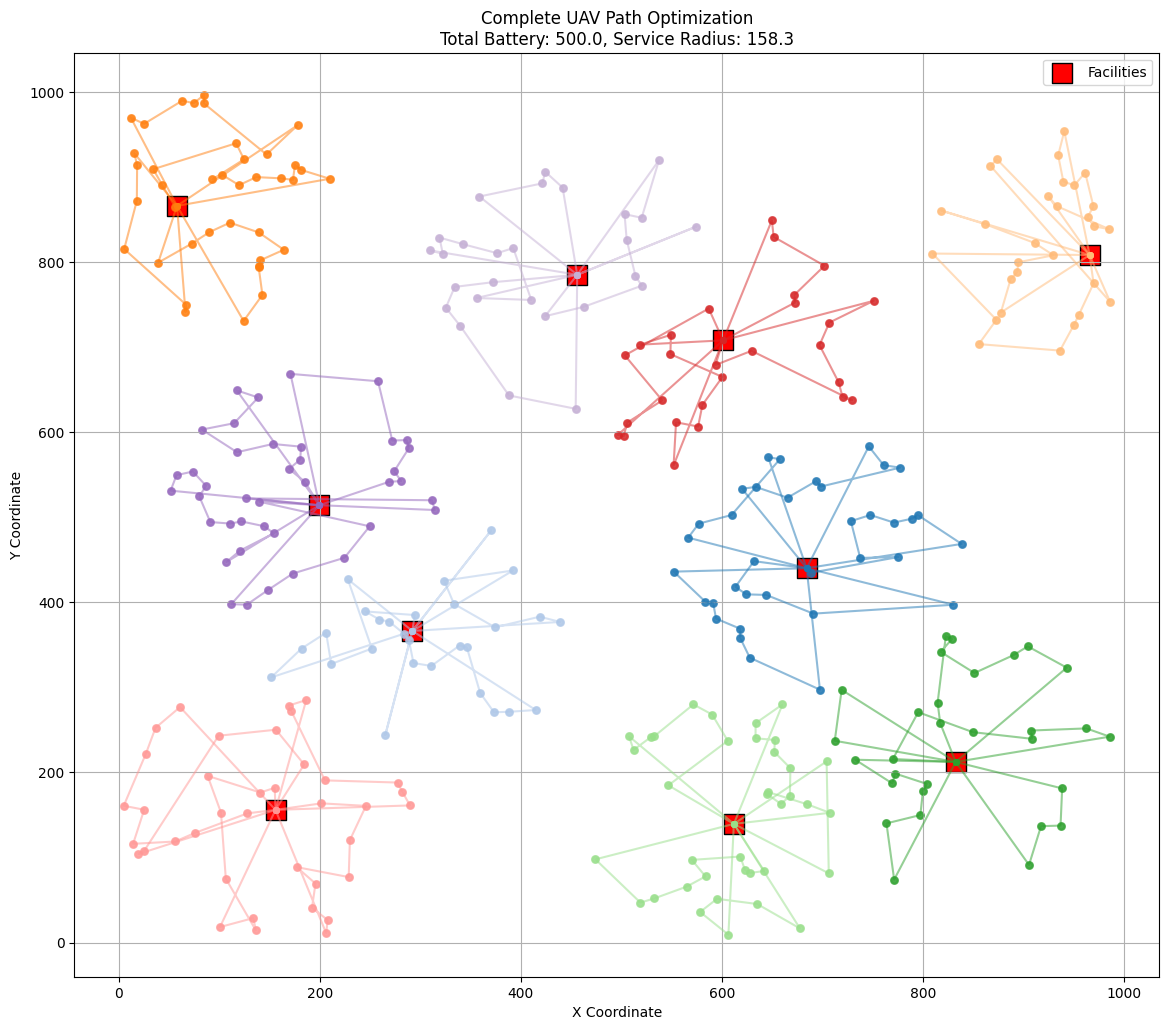


Displaying individual facility clusters...


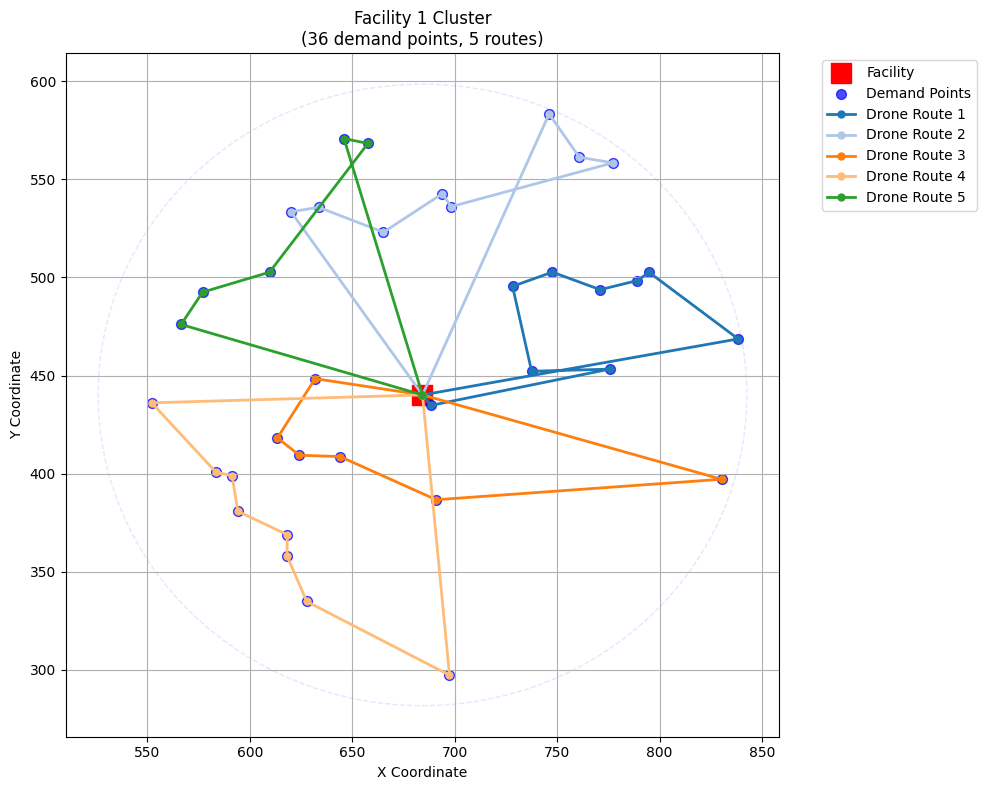

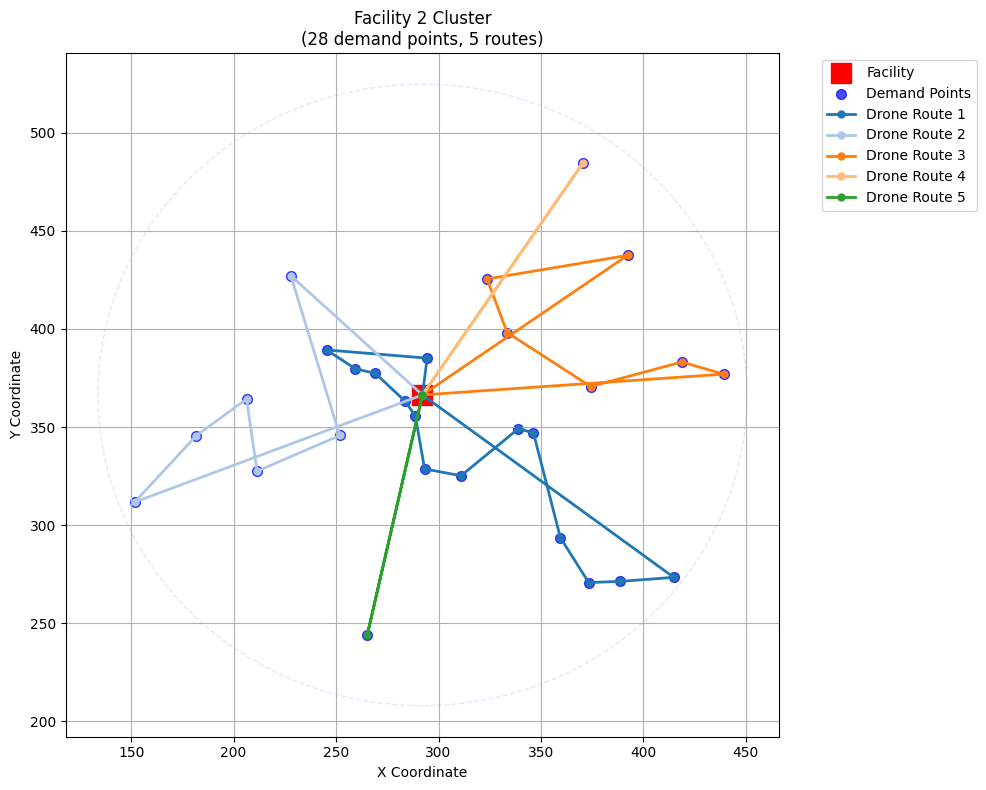

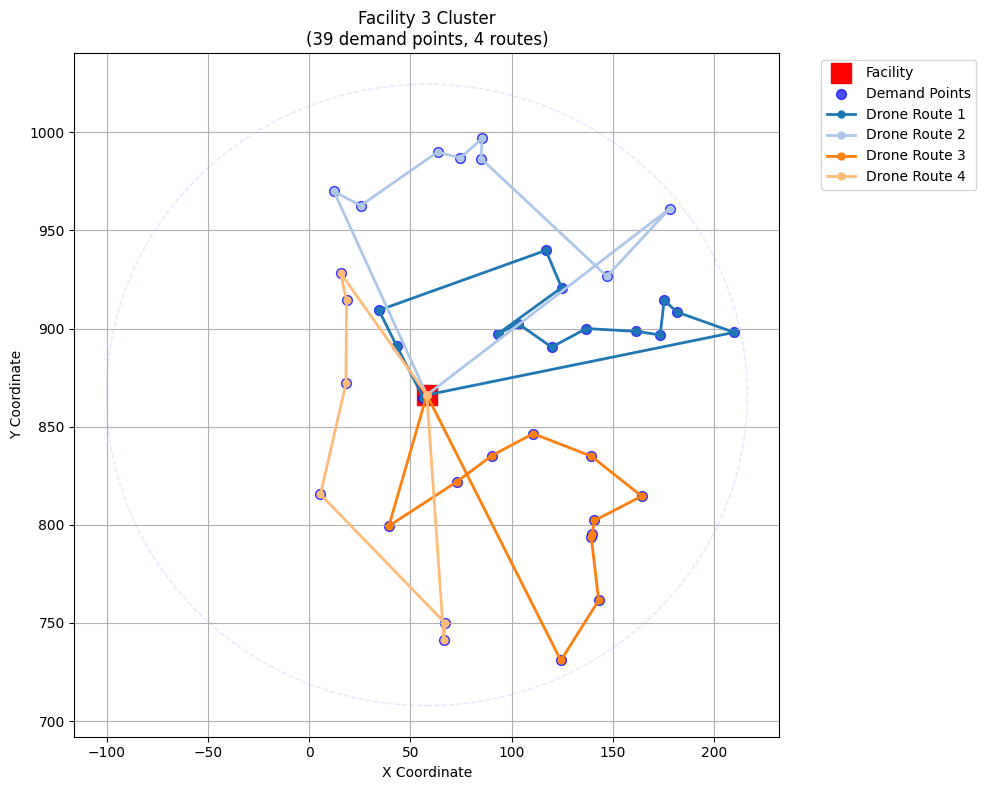

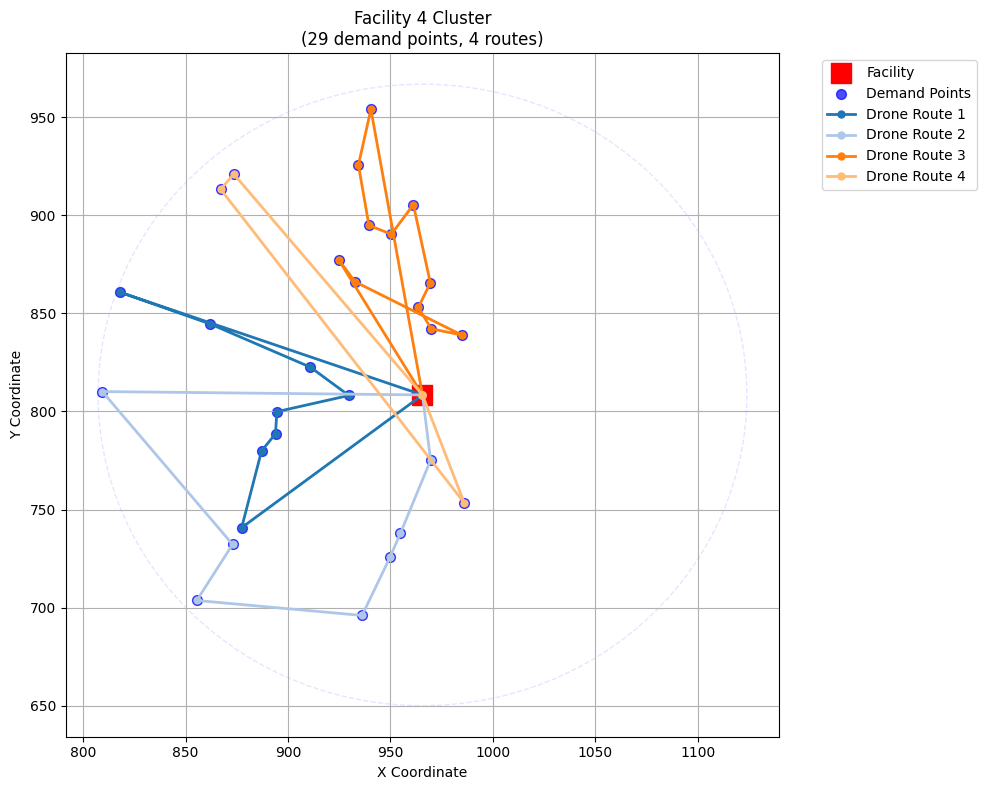

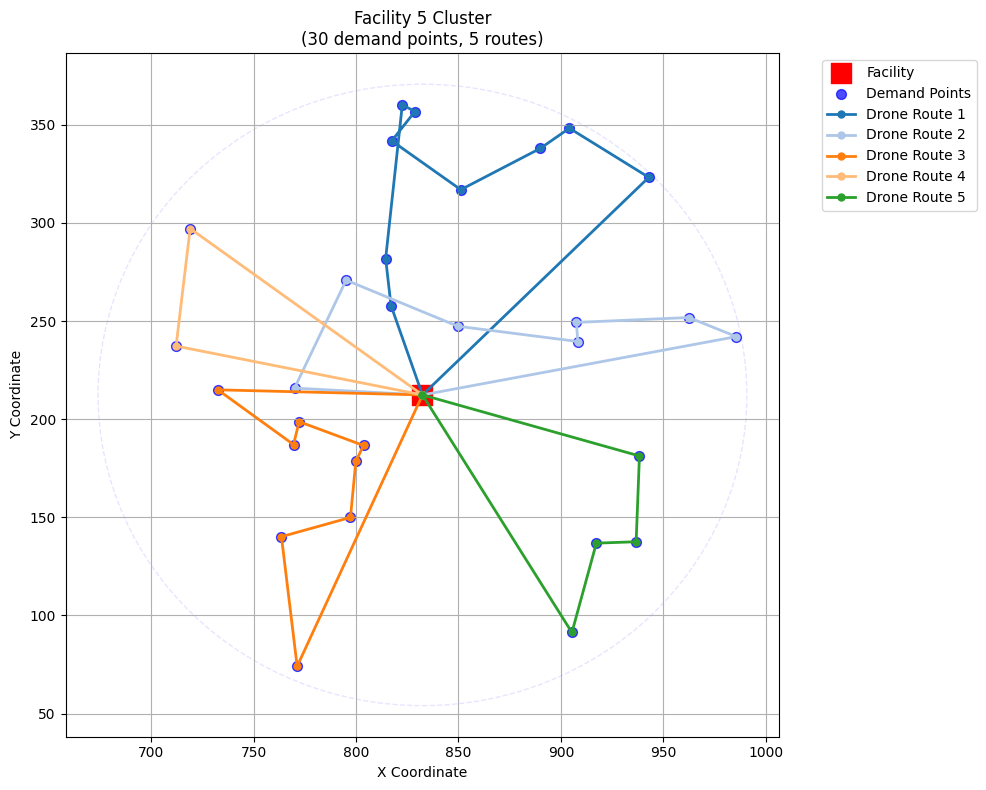

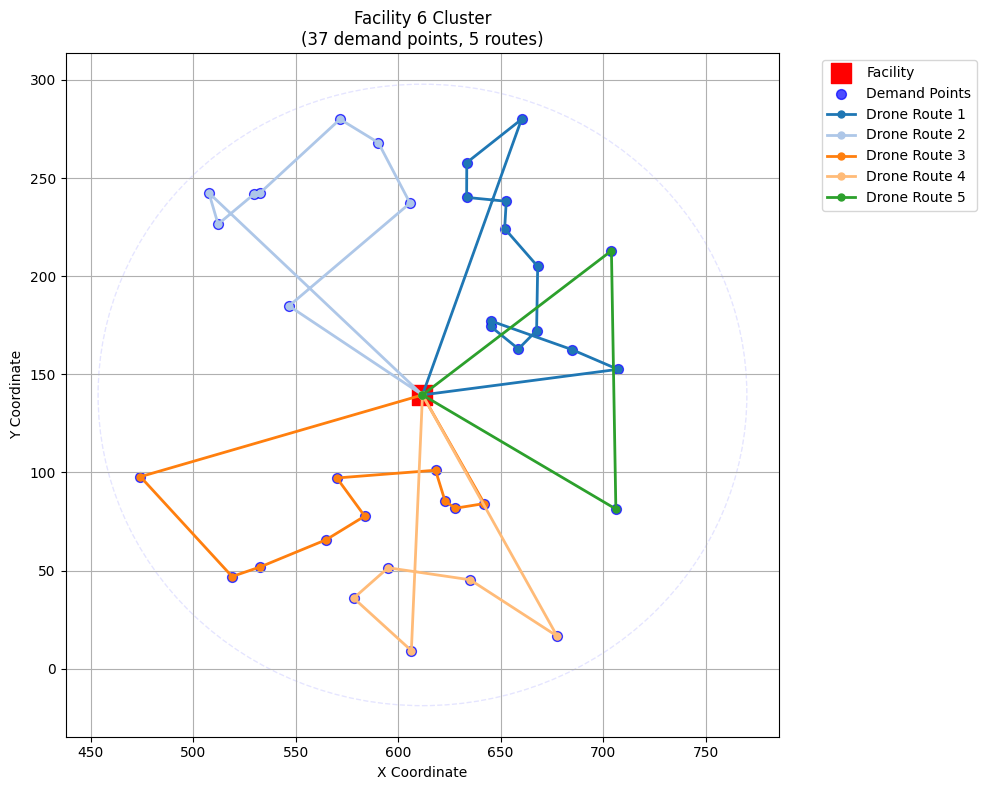

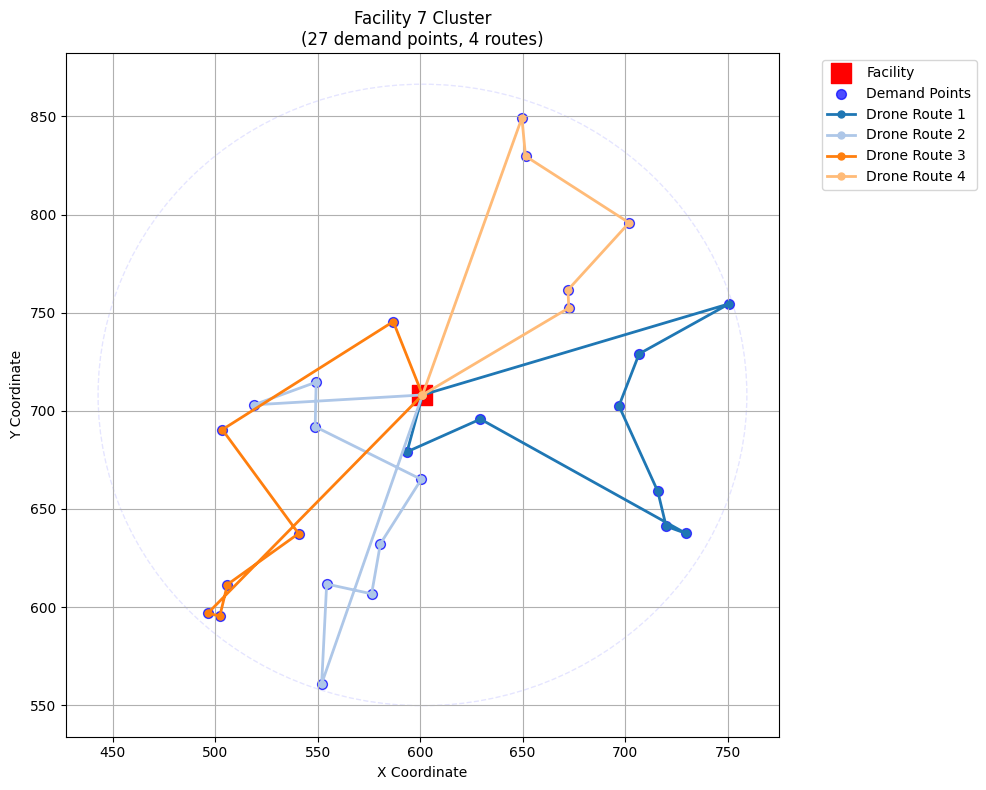

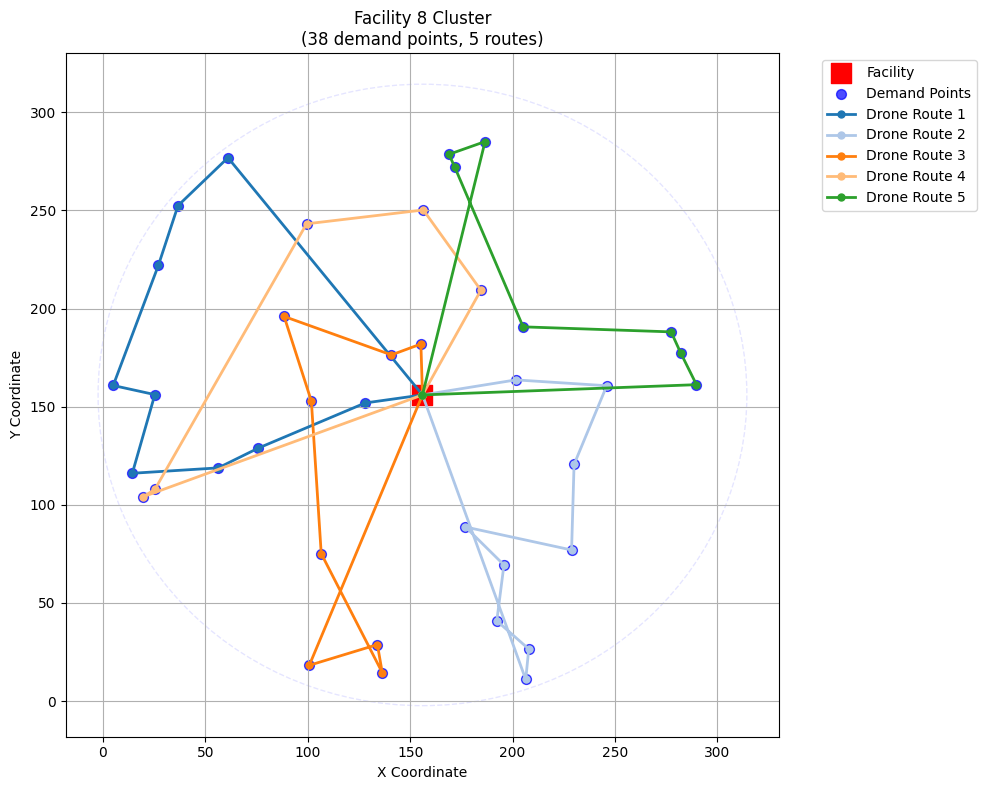

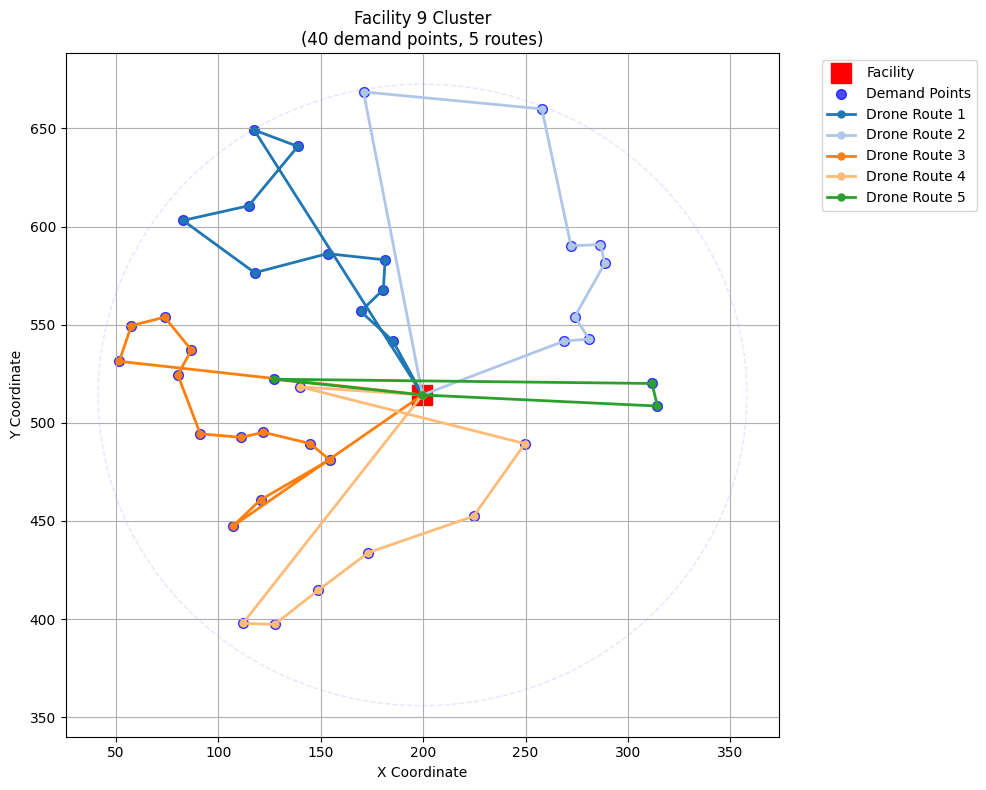

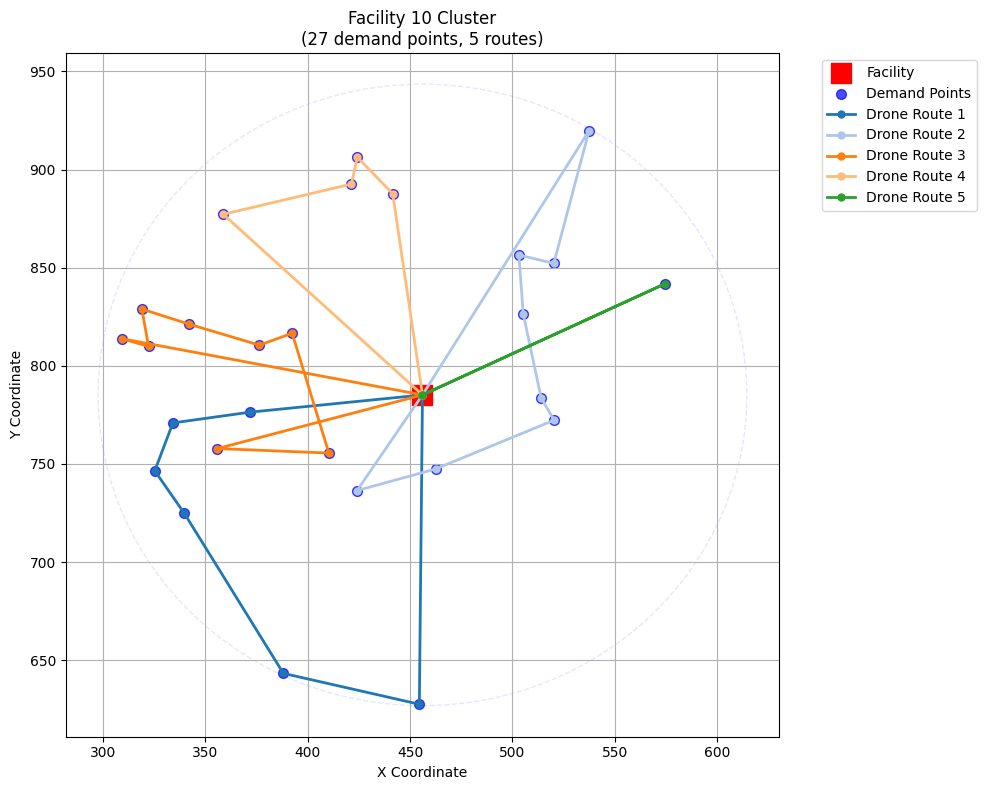


Optimization complete!


In [ ]:
import numpy as np
import math
from typing import List, Tuple, Dict, Set
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random

class UAVPathOptimizer:
    """
    UAV Path Optimizer with B/3 strategy and enhanced visualization
    """
    
    def __init__(self, facilities, demand_points, B, battery_buffer=0.9):
        self.facilities = facilities
        self.demand_points = demand_points
        self.B = B
        self.R = (B * battery_buffer) / 3
        self.clusters = self._cluster_demand_points()
        self.colors = plt.cm.tab20.colors  # Color palette for visualization

    def _distance(self, p1, p2):
        return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    def _cluster_demand_points(self):
        """Assign demand points to nearest facility within B/3 radius"""
        clusters = {fac: [] for fac in self.facilities}
        for point in self.demand_points:
            nearest_fac = min(self.facilities, key=lambda f: self._distance(f, point))
            if self._distance(nearest_fac, point) <= self.R:
                clusters[nearest_fac].append(point)
        return clusters

    def optimize_routes(self):
        """Generate optimized routes with B/3 constraints"""
        routes = {}
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            unserved = set(points)
            facility_routes = []
            
            while unserved:
                route = [fac]
                remaining_battery = self.B
                
                # Furthest-first initialization
                if not unserved:
                    break
                farthest = max(unserved, key=lambda p: self._distance(fac, p))
                dist = self._distance(fac, farthest)
                
                if dist > remaining_battery / 2:
                    break  # Can't reach and return
                
                route.append(farthest)
                unserved.remove(farthest)
                remaining_battery -= dist
                
                # Nearest-neighbor greedy addition
                while unserved and remaining_battery > 0:
                    current_pos = route[-1]
                    next_point = None
                    min_dist = float('inf')
                    
                    for p in unserved:
                        dist = self._distance(current_pos, p)
                        return_dist = self._distance(p, fac)
                        if dist + return_dist <= remaining_battery and dist < min_dist:
                            min_dist = dist
                            next_point = p
                            
                    if next_point is None:
                        break
                        
                    route.append(next_point)
                    unserved.remove(next_point)
                    remaining_battery -= min_dist
                
                # Return to facility
                route.append(fac)
                facility_routes.append(route)
            
            routes[fac] = facility_routes
            
        return routes

    def visualize_clusters(self):
        """Visualize facility clusters with service radius"""
        plt.figure(figsize=(12, 10))
        
        # Plot all demand points (gray)
        all_x, all_y = zip(*self.demand_points)
        plt.scatter(all_x, all_y, c='lightgray', s=20, alpha=0.5, label='Unserved Demand')
        
        # Plot facilities and their clusters
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            fac_x, fac_y = fac
            
            # Draw service radius
            circle = plt.Circle(fac, self.R, color=self.colors[fac_idx % 20], 
                              alpha=0.1, linestyle='--', fill=False)
            plt.gca().add_patch(circle)
            
            # Plot facility
            plt.scatter(fac_x, fac_y, c=[self.colors[fac_idx % 20]], 
                       s=200, marker='s', edgecolor='k', label=f'Facility {fac_idx+1}')
            
            # Plot served points
            if points:
                cluster_x, cluster_y = zip(*points)
                plt.scatter(cluster_x, cluster_y, c=[self.colors[fac_idx % 20]], 
                           s=50, alpha=0.7)
        
        plt.title(f"Facility Clusters with B/3 Service Radius (R = {self.R:.1f})")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def visualize_all_routes(self, routes):
        """Static visualization of all routes"""
        plt.figure(figsize=(14, 12))
        
        # Plot facilities
        fac_x, fac_y = zip(*self.facilities)
        plt.scatter(fac_x, fac_y, c='red', s=200, marker='s', edgecolor='k', label='Facilities')
        
        # Plot demand points
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            if points:
                x, y = zip(*points)
                plt.scatter(x, y, c=[self.colors[fac_idx % 20]], s=30, alpha=0.7)
        
        # Plot routes
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            for route in fac_routes:
                x, y = zip(*route)
                plt.plot(x, y, 'o-', c=self.colors[fac_idx % 20], 
                        alpha=0.5, lw=1.5, ms=4)
        
        plt.title(f"Complete UAV Path Optimization\nTotal Battery: {self.B}, Service Radius: {self.R:.1f}")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_individual_facility_clusters(self, routes):
        """Generate separate cluster plots for each facility showing its routes"""
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            plt.figure(figsize=(10, 8))
            
            # Plot facility
            plt.scatter(fac[0], fac[1], c='red', s=200, marker='s', label='Facility')
            
            # Draw service radius
            circle = plt.Circle(fac, self.R, color='blue', alpha=0.1, linestyle='--', fill=False)
            plt.gca().add_patch(circle)
            
            # Plot all demand points in this cluster
            cluster_points = self.clusters[fac]
            if cluster_points:
                cluster_x, cluster_y = zip(*cluster_points)
                plt.scatter(cluster_x, cluster_y, c='blue', s=50, alpha=0.7, label='Demand Points')
            
            # Plot routes with different colors
            for route_idx, route in enumerate(fac_routes):
                route_x, route_y = zip(*route)
                plt.plot(route_x, route_y, 'o-', 
                         color=self.colors[route_idx % 20],
                         linewidth=2,
                         markersize=5,
                         label=f'Drone Route {route_idx+1}')
            
            plt.title(f'Facility {fac_idx+1} Cluster\n({len(cluster_points)} demand points, {len(fac_routes)} routes)')
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    import numpy as np
    
    # ======================
    # USER-CONFIGURABLE PARAMETERS
    # ======================
    # Edit these values directly in the script before running
    
    # Problem Parameters
    p = 10                # Maximum number of facilities to open (integer)
    K = 100               # Total drones available (integer)
    U = 1000.0            # Facility capacity (float)
    B = 500.0            # Drone battery capacity (float)
    battery_buffer = 0.95 # Battery safety margin (0-1, float)
    
    # Data Generation Parameters
    num_facility_locations = 20  # Potential locations to choose from (integer)
    num_demand_points = 500      # Total demand points (integer)
    random_seed = 42             # For reproducible results (integer)
    area_size = 1000.0            # Size of operational area in km (float)
    
    # Visualization Options
    show_cluster_plot = True     # Show facility clusters visualization
    show_route_plot = True       # Show complete routes visualization
    show_individual_clusters = True # Show individual facility clusters
    
    # ======================
    # DATA GENERATION
    # ======================
    np.random.seed(random_seed)
    
    print("Generating problem instance...")
    facility_locations = [(np.random.uniform(0, area_size), 
                         np.random.uniform(0, area_size)) 
                         for _ in range(num_facility_locations)]
    
    demand_points = [(np.random.uniform(0, area_size), 
                    np.random.uniform(0, area_size)) 
                    for _ in range(num_demand_points)]
    
    # Calculate distances (battery consumption)
    def euclidean_distance(a, b):
        return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    
    # ======================
    # FACILITY SELECTION
    # ======================
    print("Selecting optimal facility locations...")
    kmeans = KMeans(n_clusters=p, random_state=random_seed)
    coords = np.array(demand_points)
    kmeans.fit(coords)
    
    selected_facilities = []
    for center in kmeans.cluster_centers_:
        nearest_fac = min(facility_locations, 
                         key=lambda f: euclidean_distance(f, tuple(center)))
        selected_facilities.append(nearest_fac)
    
    # ======================
    # RUN OPTIMIZATION
    # ======================
    print("Running UAV path optimization...")
    optimizer = UAVPathOptimizer(
        facilities=selected_facilities,
        demand_points=demand_points,
        B=B,
        battery_buffer=battery_buffer
    )
    
    routes = optimizer.optimize_routes()
    
    # ======================
    # RESULTS
    # ======================
    print("\nOptimization Results:")
    print("====================")
    
    total_routes = sum(len(r) for r in routes.values())
    served = sum(len(route)-2 for fac_routes in routes.values() for route in fac_routes)
    
    print(f"Facilities opened: {len(selected_facilities)}/{p}")
    print(f"Total demand points: {num_demand_points}")
    print(f"Demand points served: {served} ({served/num_demand_points:.1%})")
    print(f"Total routes generated: {total_routes}")
    print(f"Drone utilization: {total_routes}/{K} ({total_routes/K:.1%})")
    print(f"Average points per route: {served/total_routes:.1f}")
    
    # ======================
    # VISUALIZATION
    # ======================
    if show_cluster_plot:
        print("\nDisplaying facility clusters...")
        optimizer.visualize_clusters()
    
    if show_route_plot:
        print("\nDisplaying complete route visualization...")
        optimizer.visualize_all_routes(routes)
    
    if show_individual_clusters:
        print("\nDisplaying individual facility clusters...")
        optimizer.plot_individual_facility_clusters(routes)
    
    print("\nOptimization complete!")

Generating problem instance...
Selecting optimal facility locations...
Running UAV path optimization...

Optimization Results:
Facilities opened: 30/30
Total demand points: 1000
Demand points served: 996 (99.6%)
Total routes generated: 86
Drone utilization: 86/100 (86.0%)
Average points per route: 11.6

Displaying facility clusters...


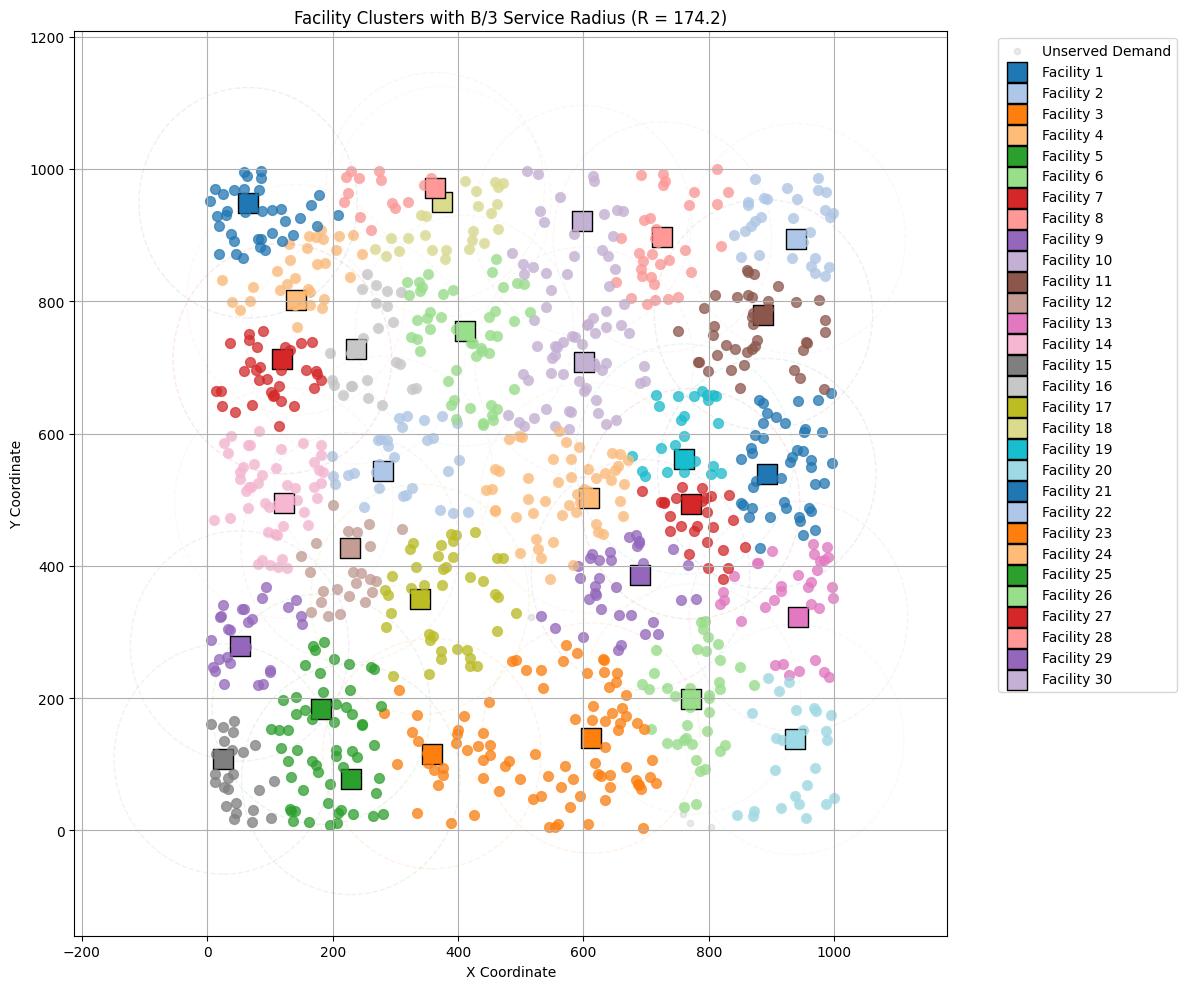


Displaying complete route visualization...


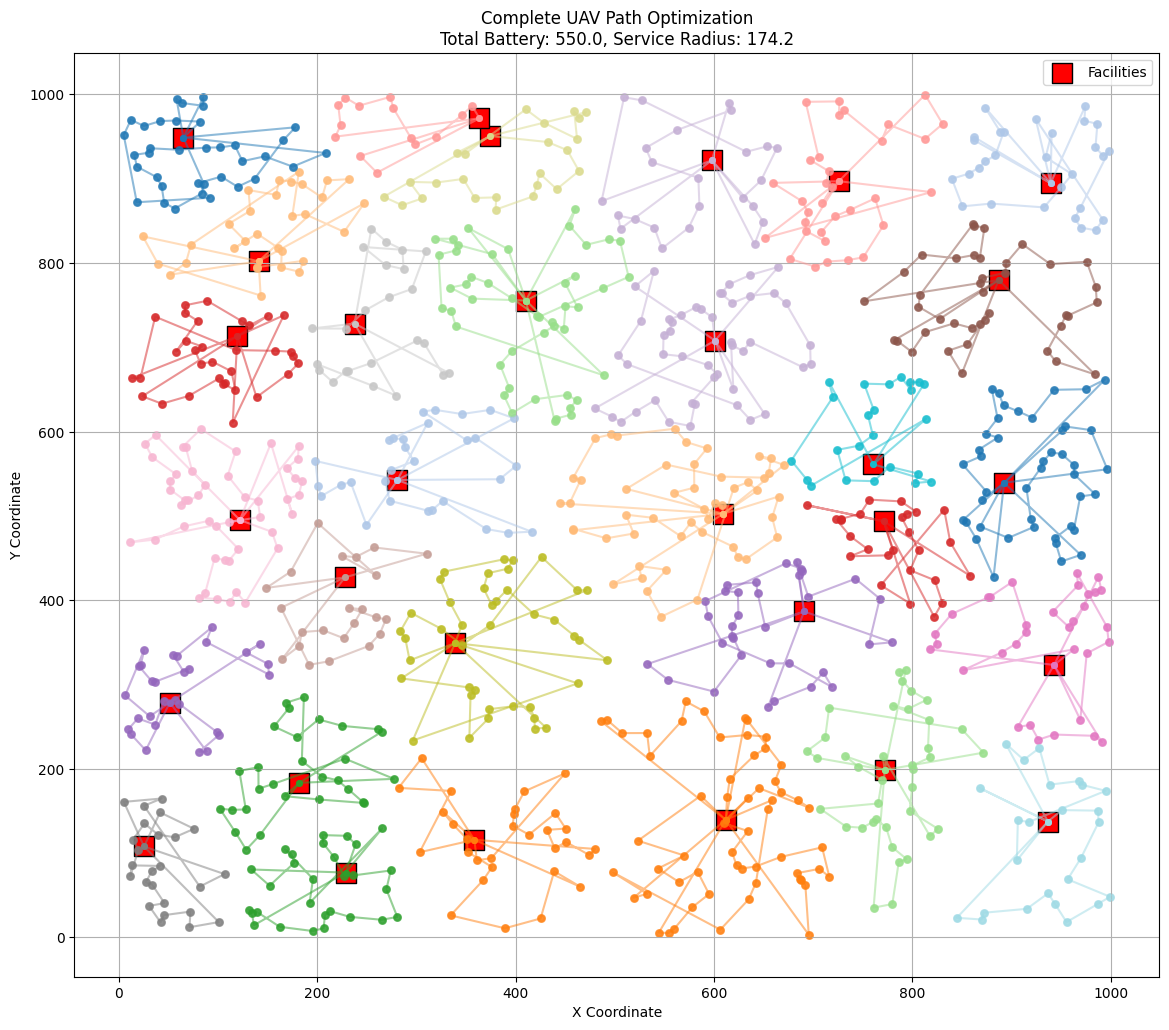


Displaying individual facility clusters...


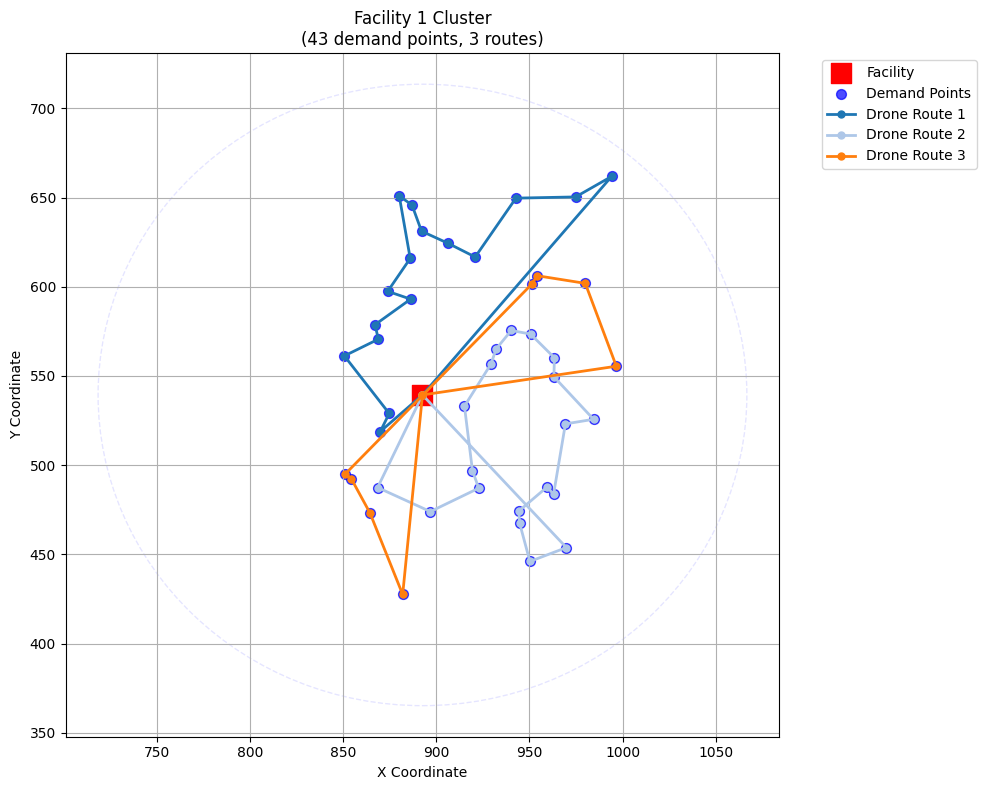

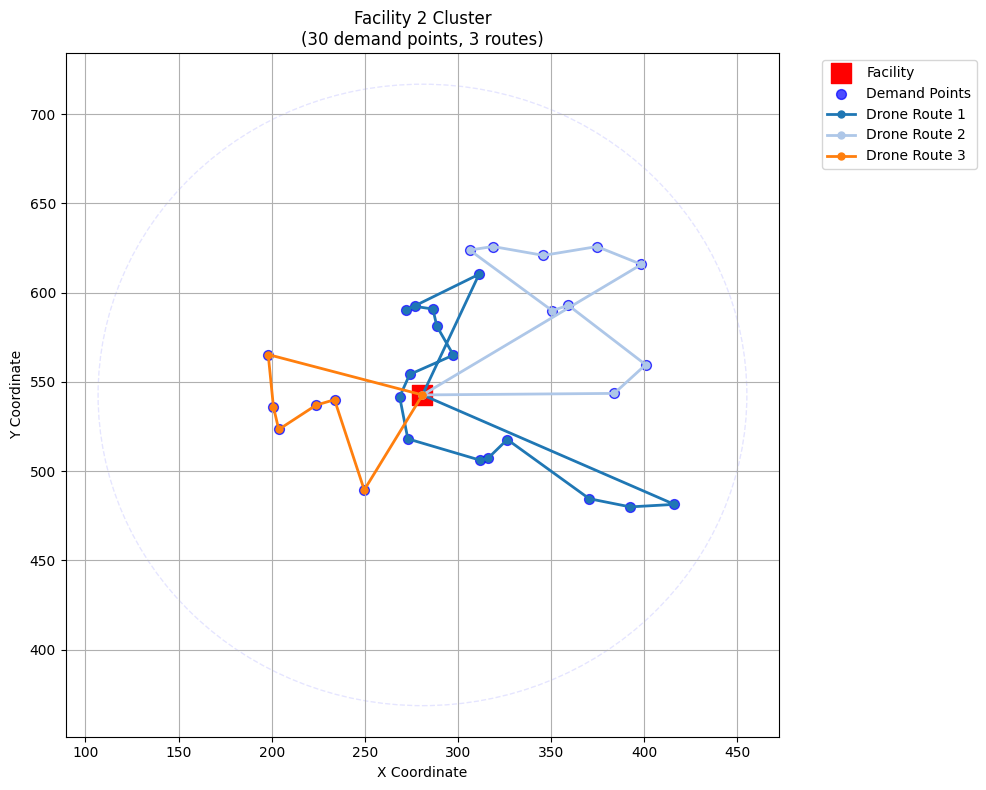

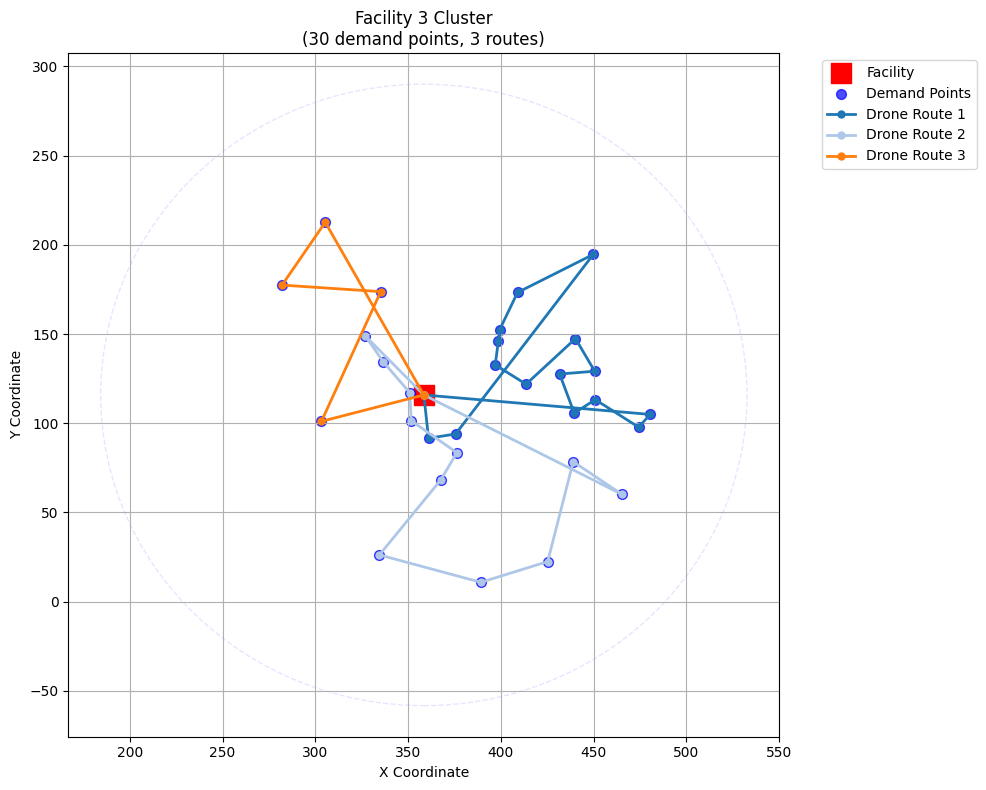

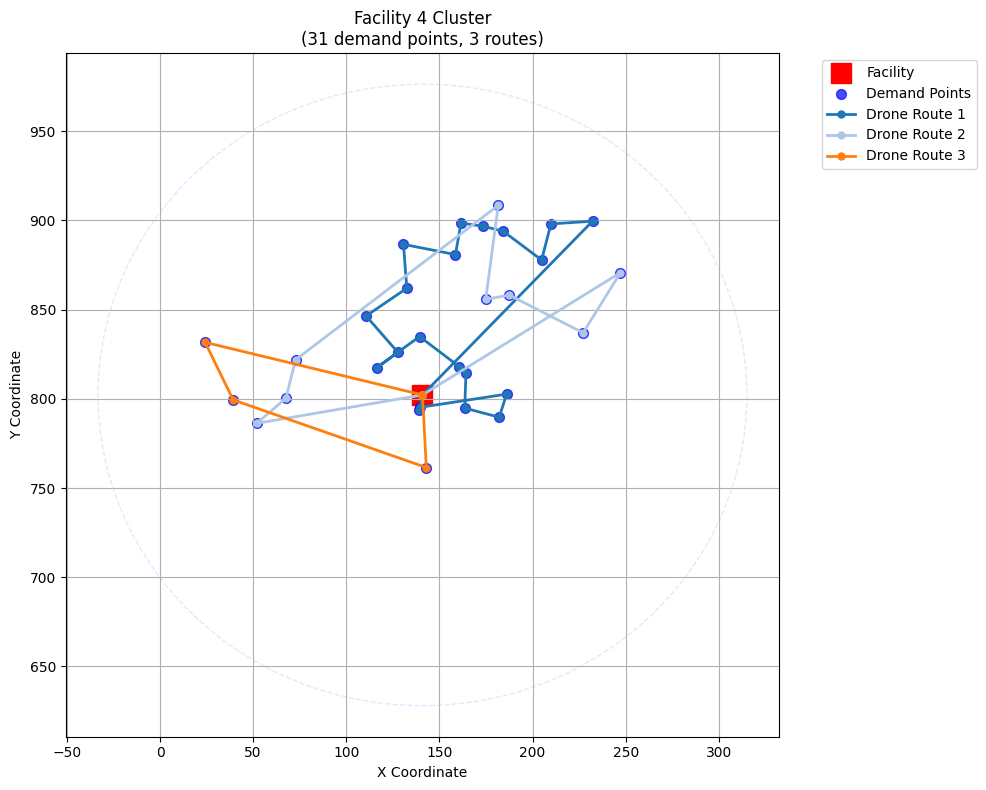

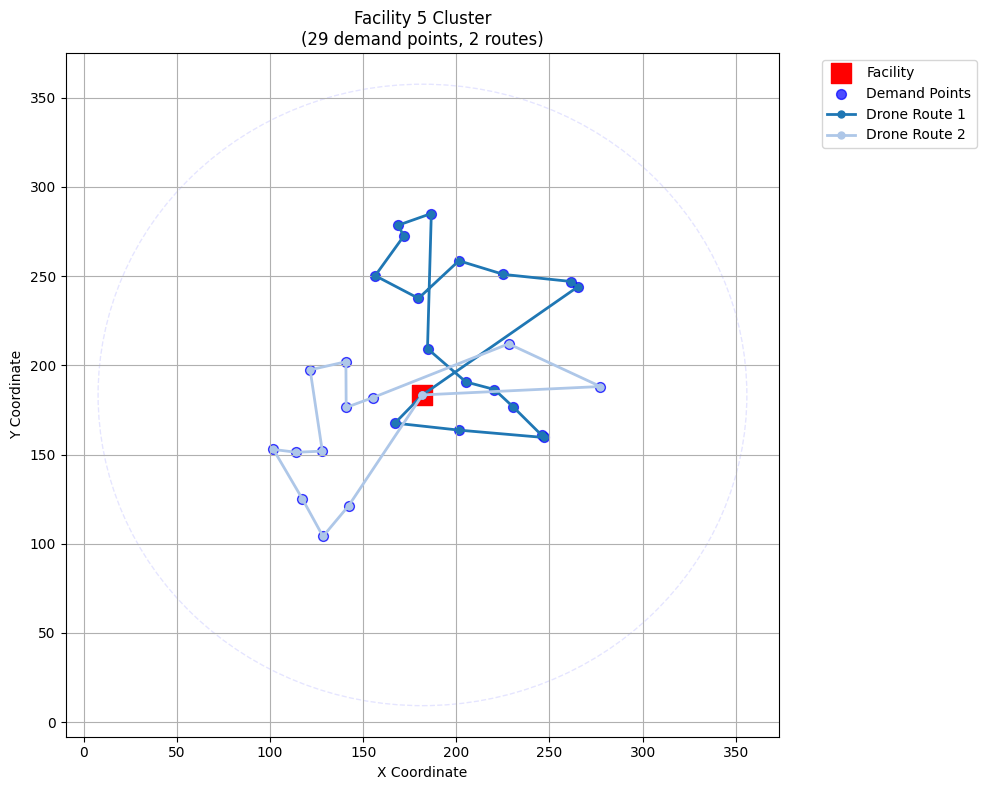

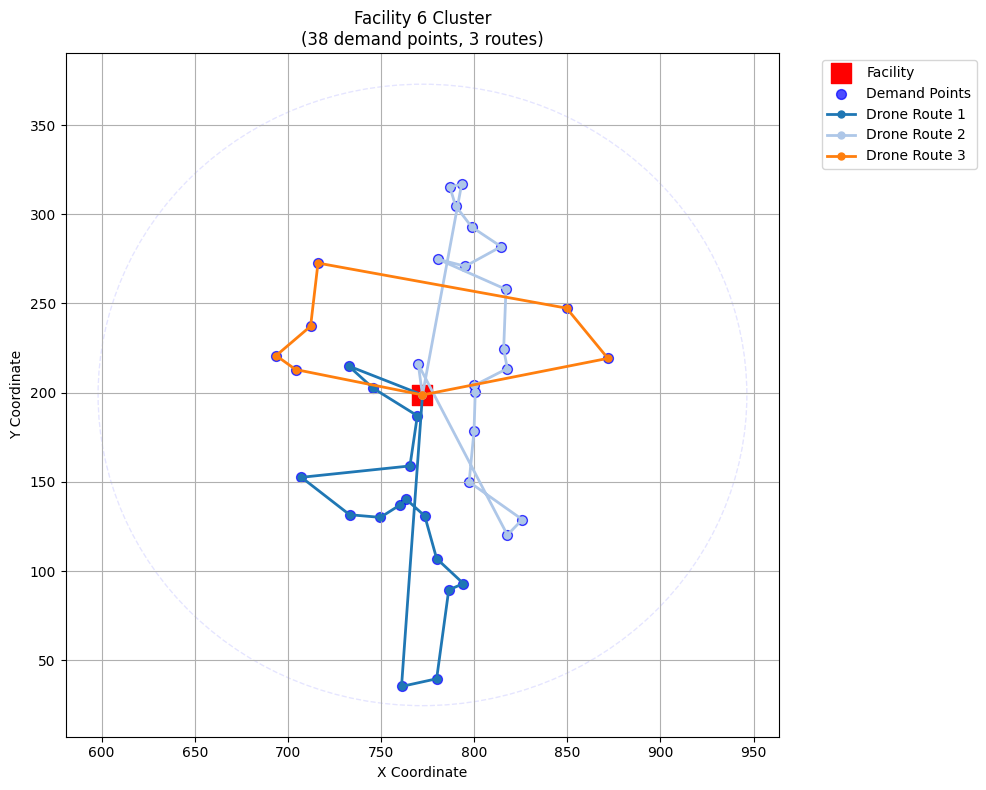

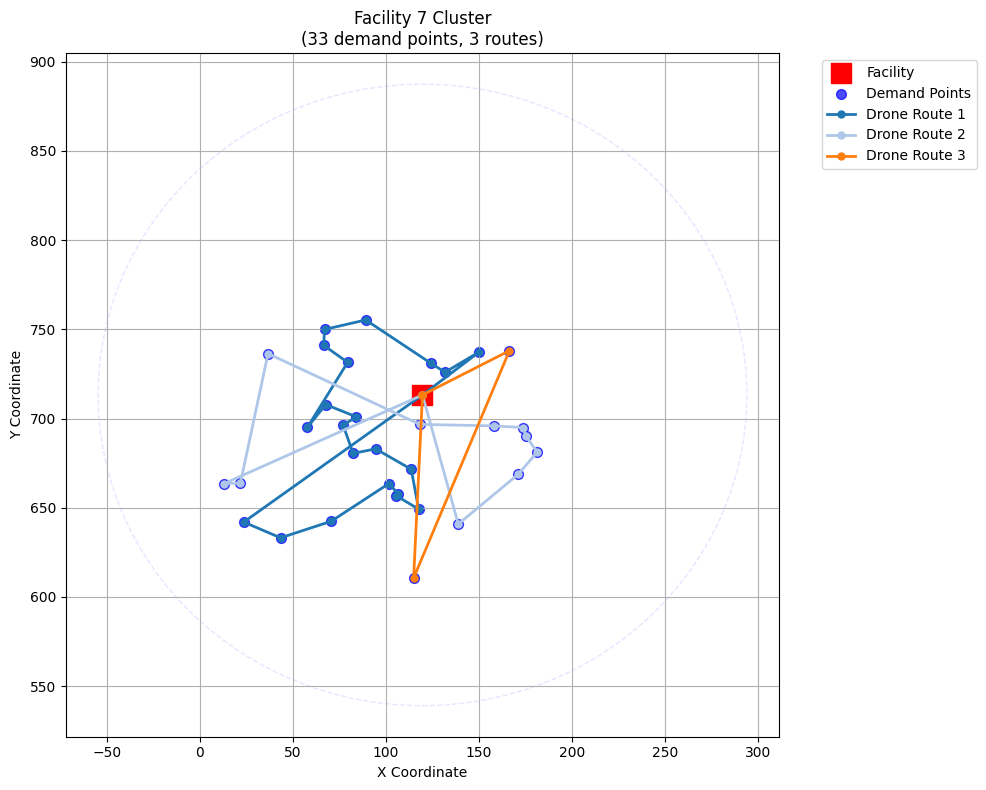

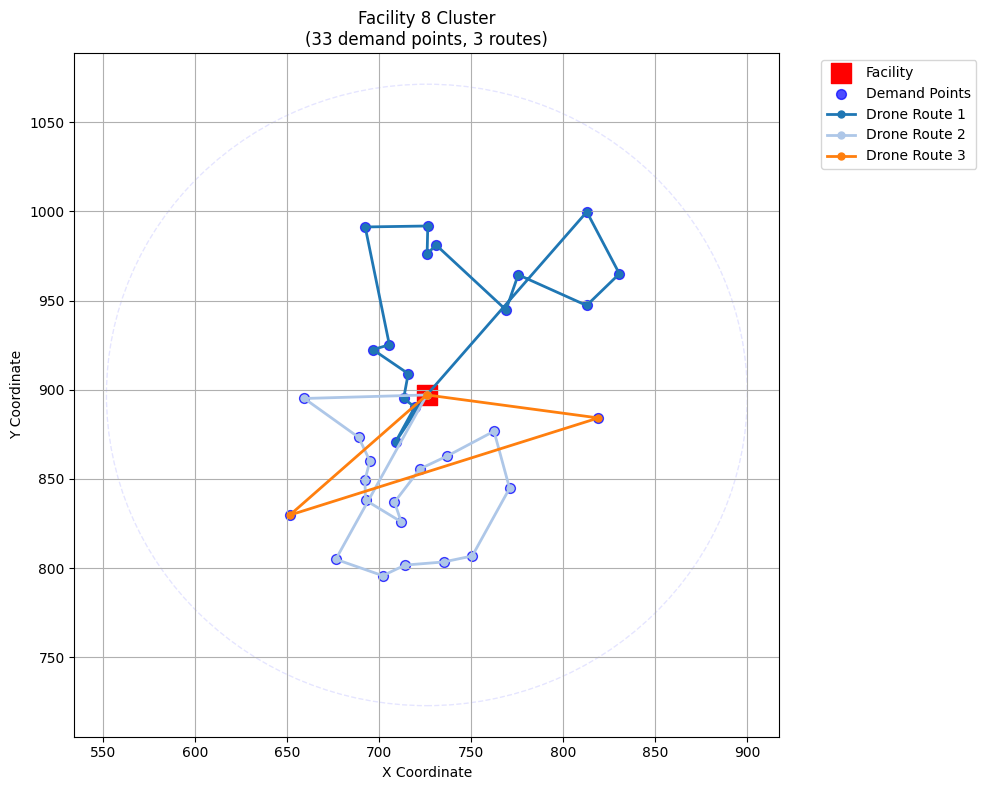

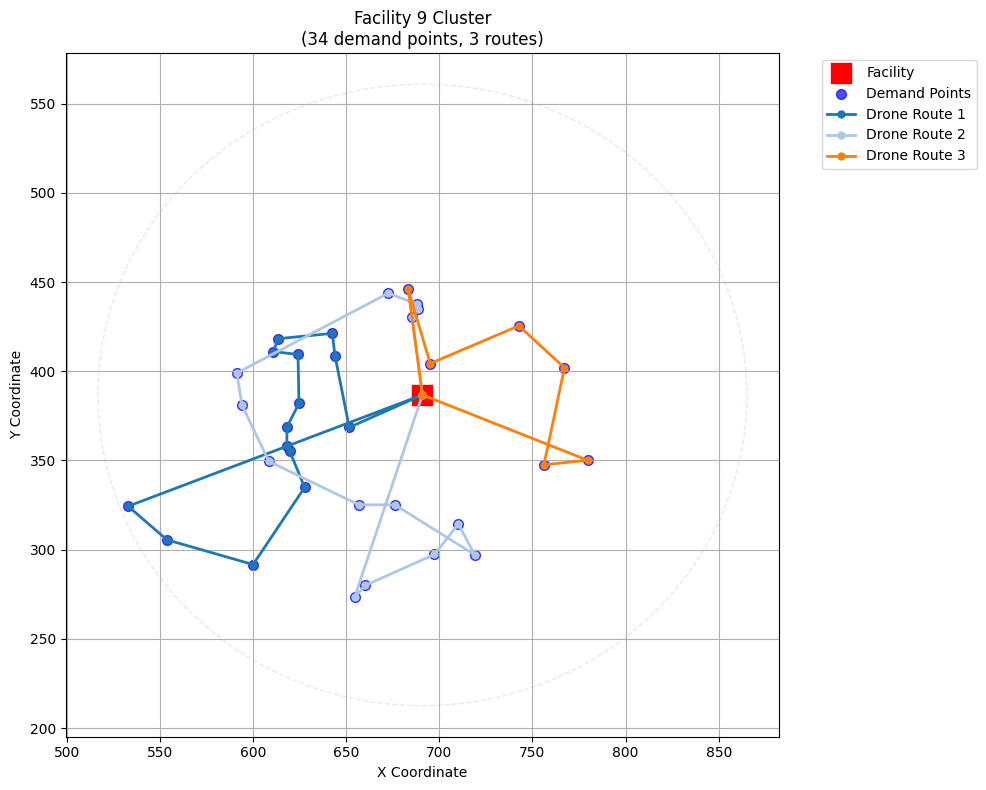

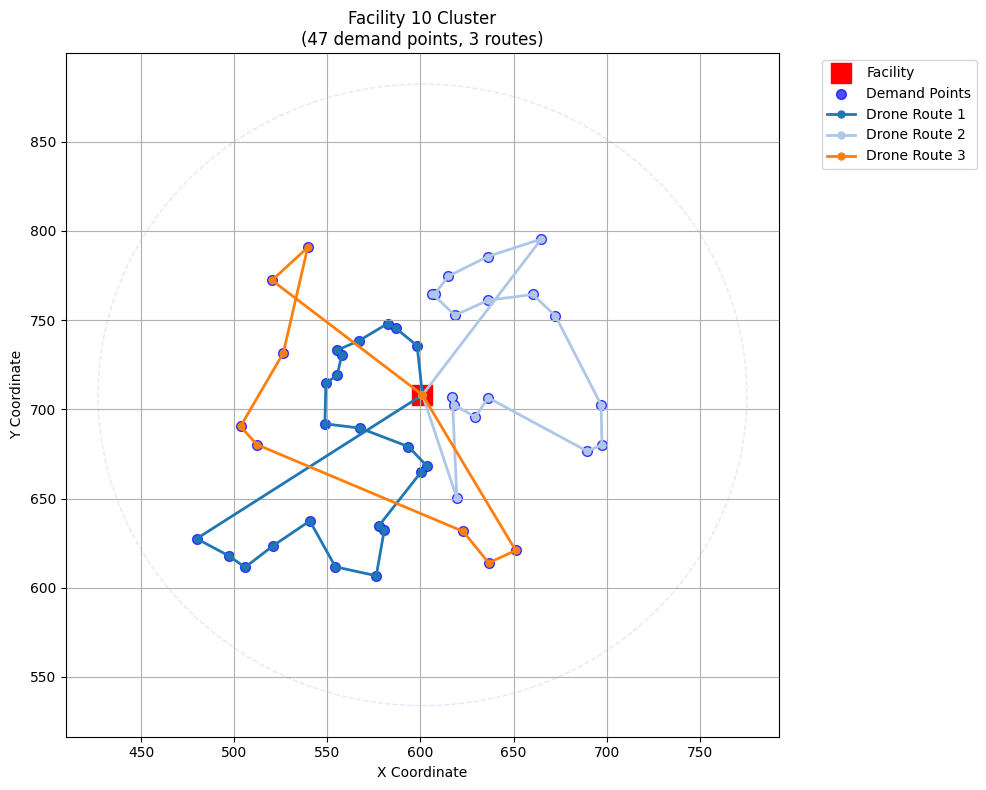

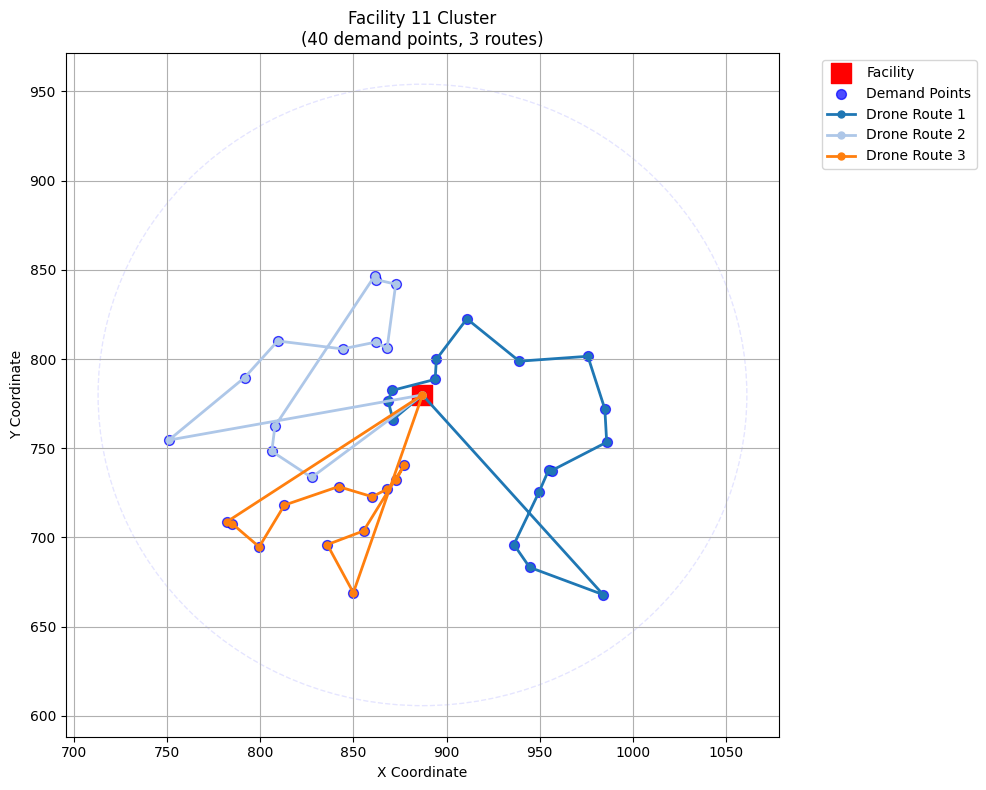

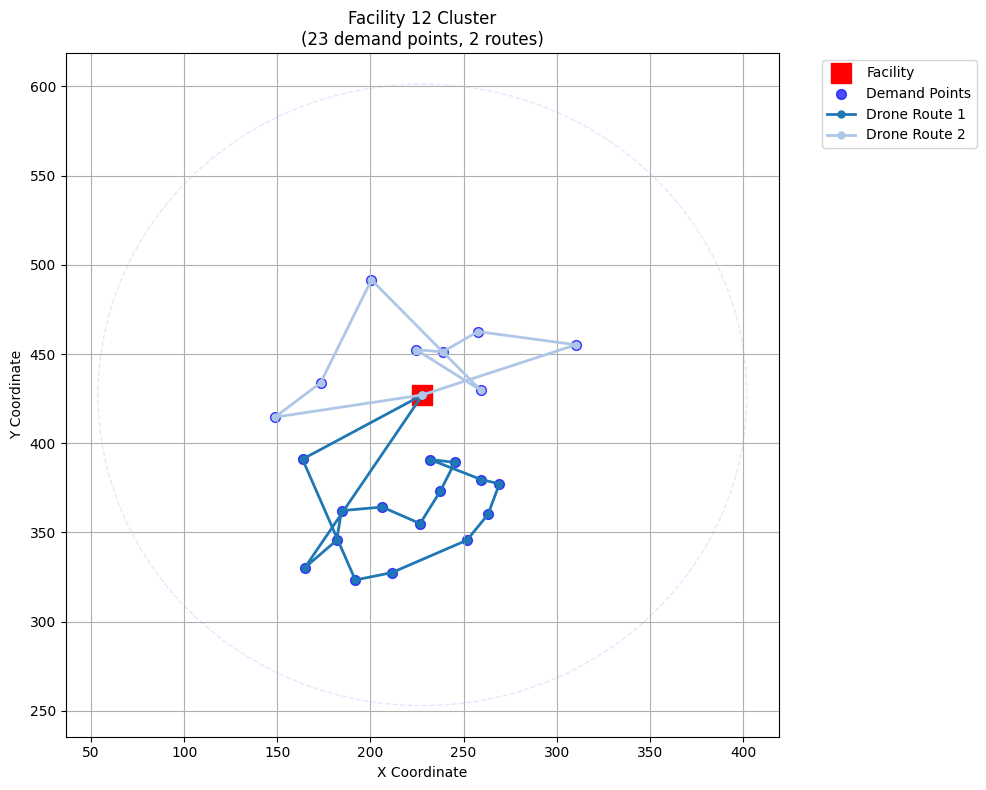

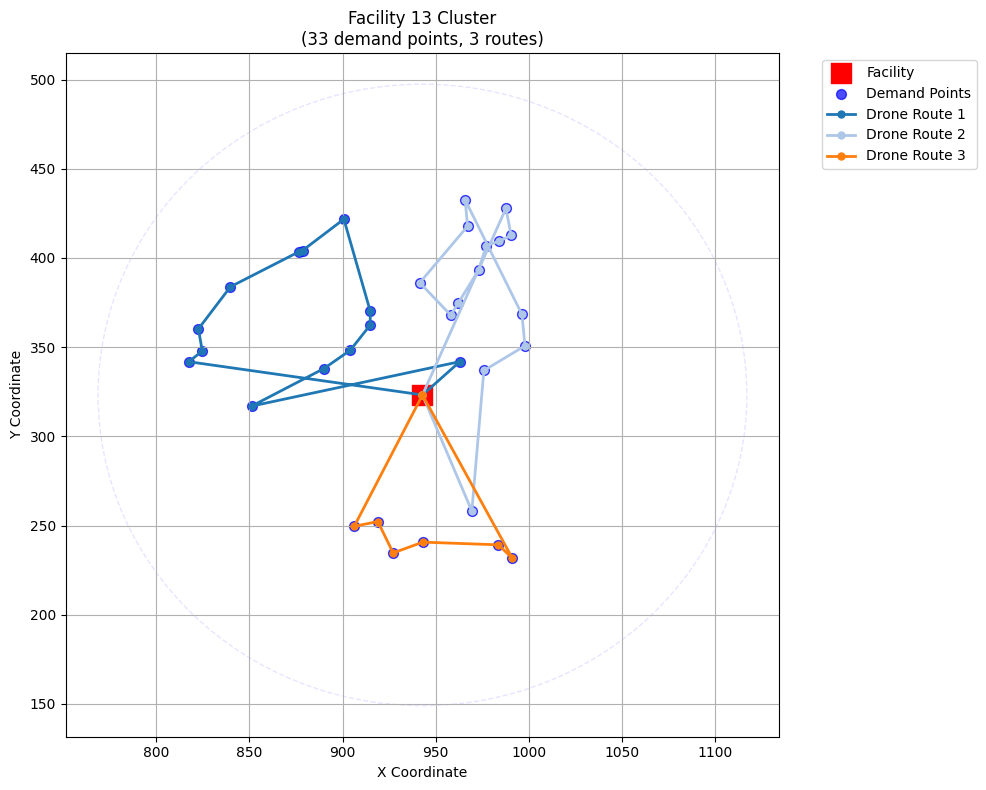

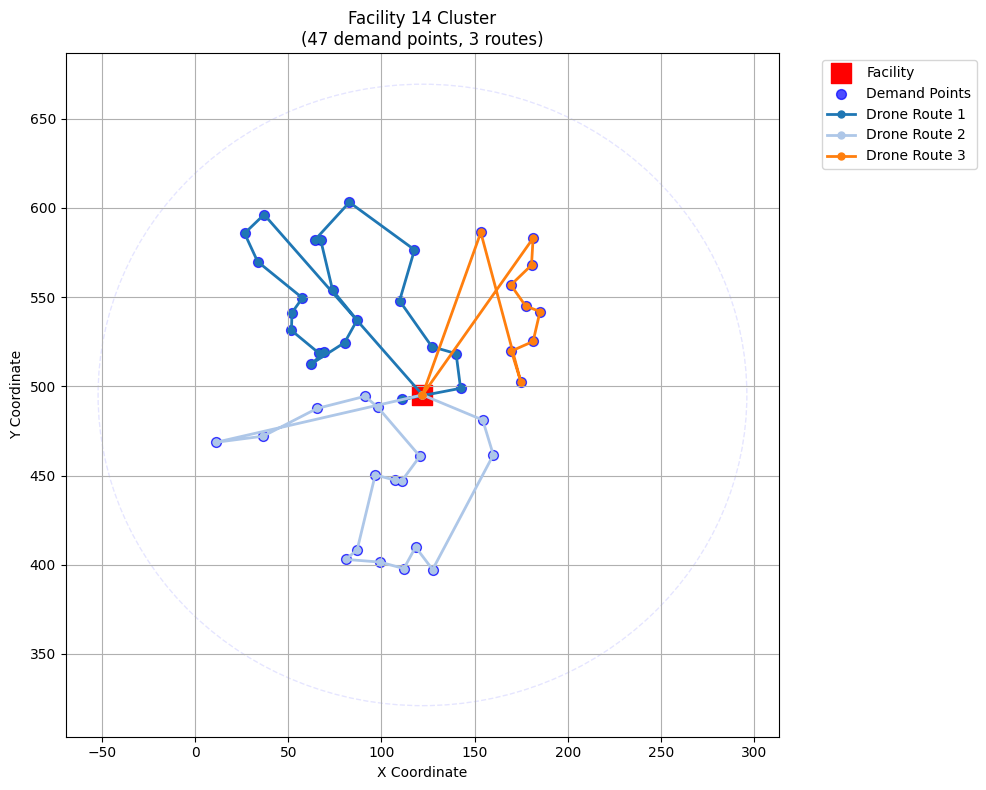

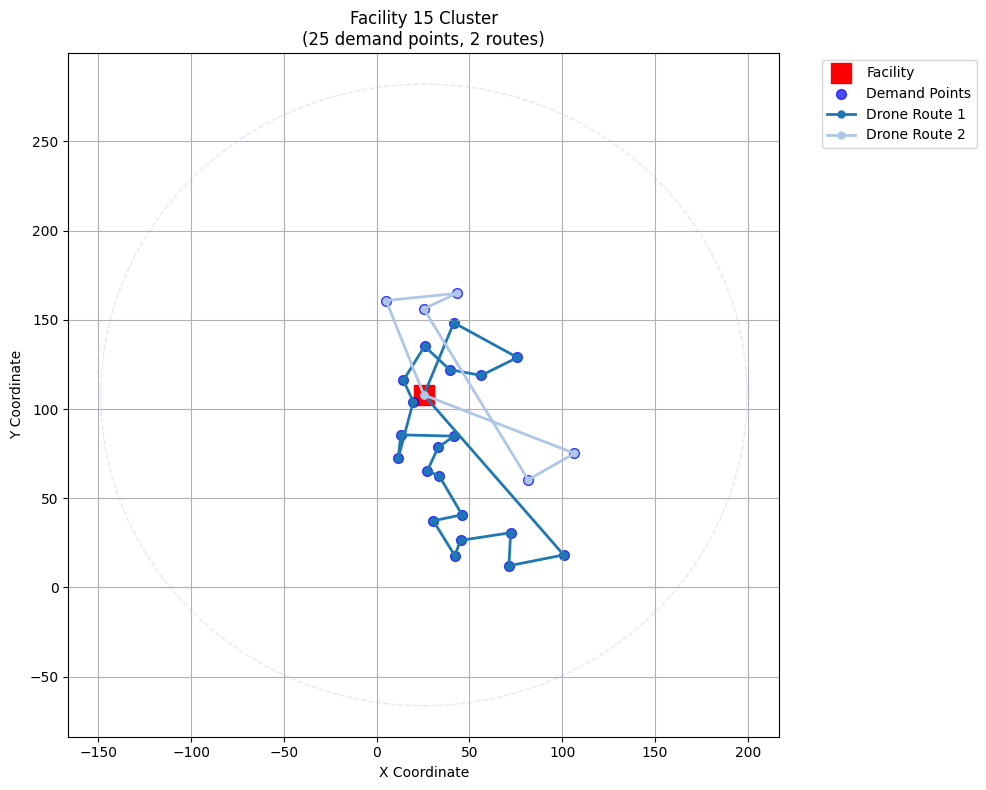

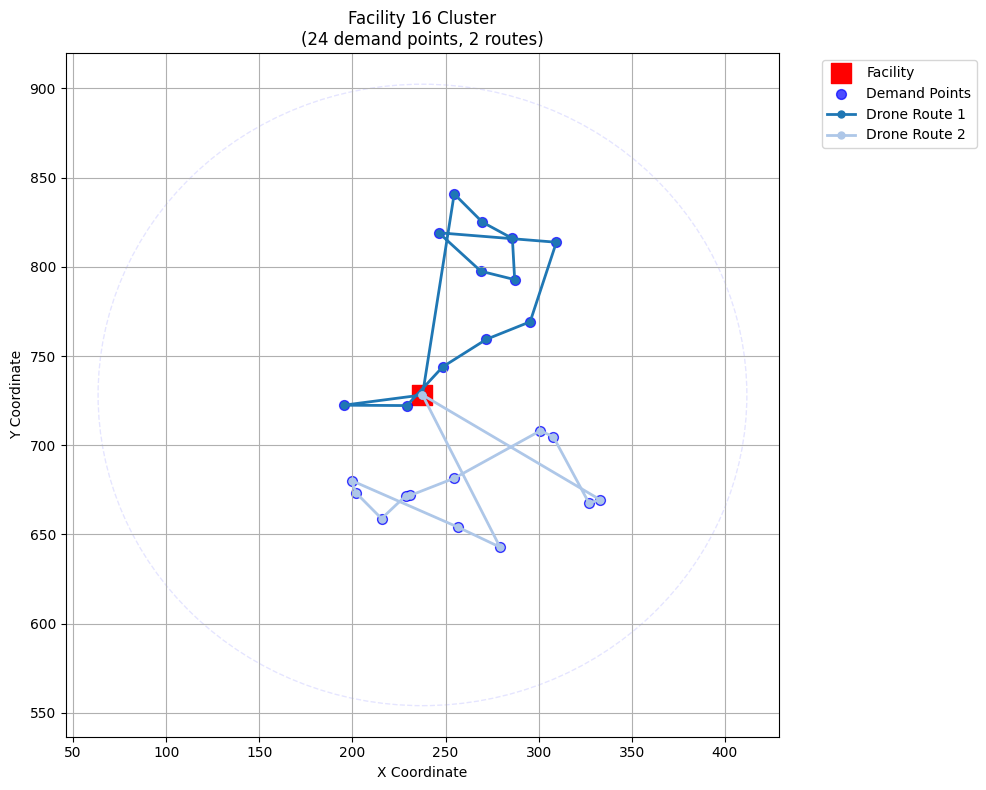

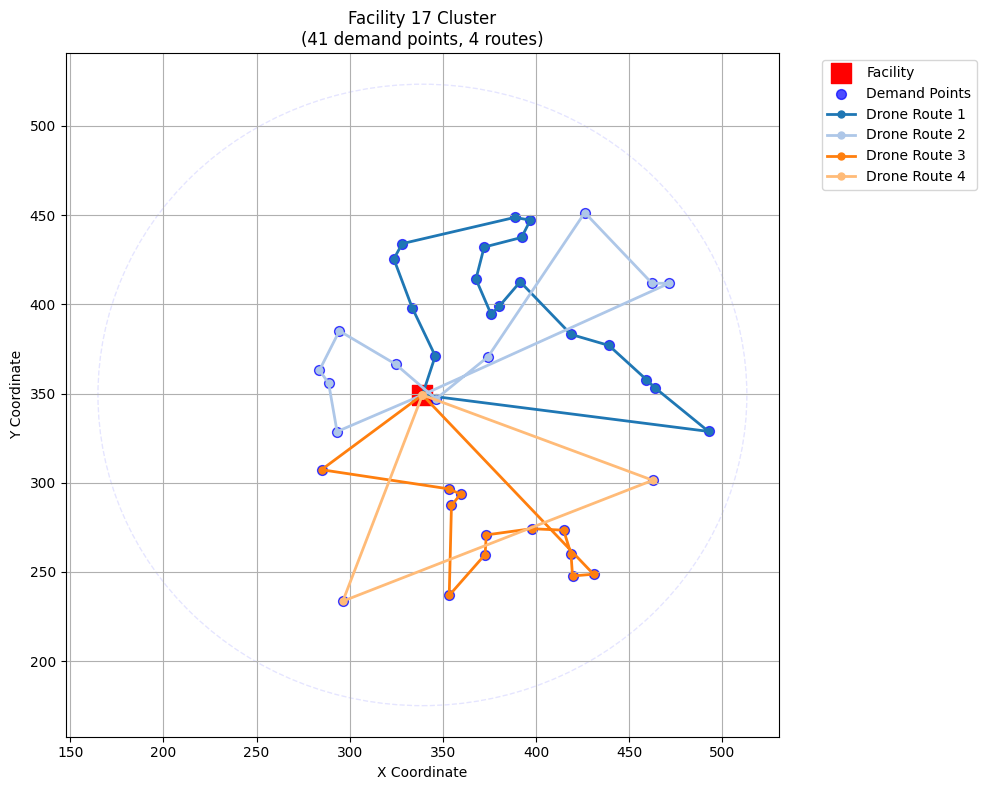

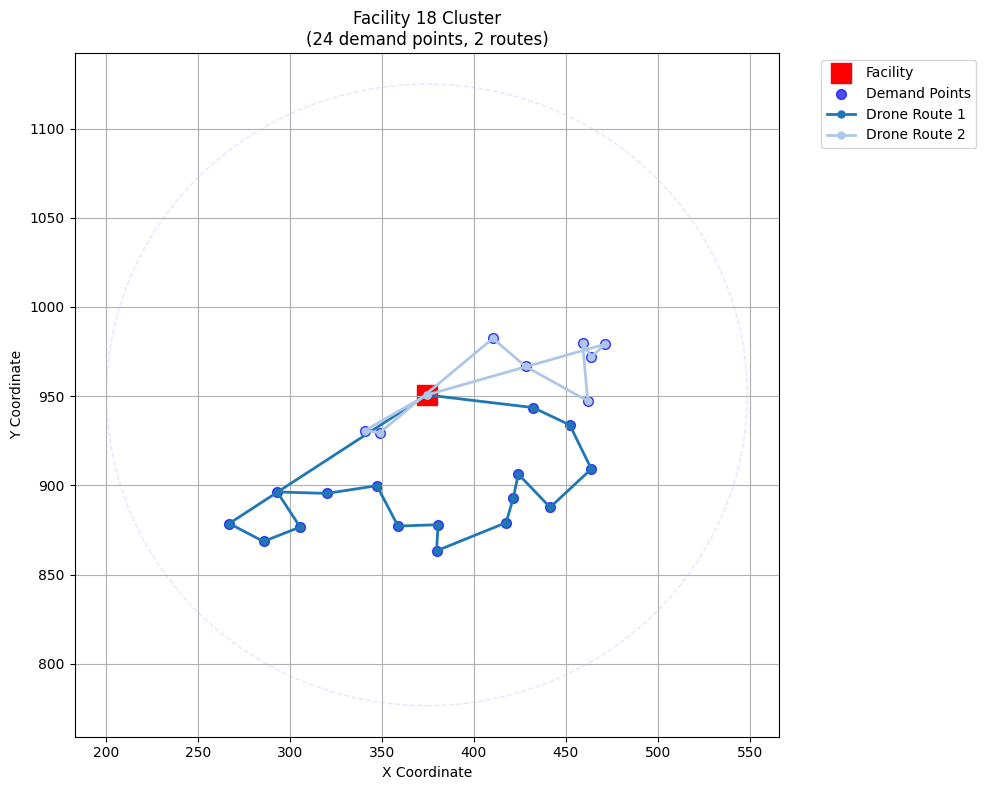

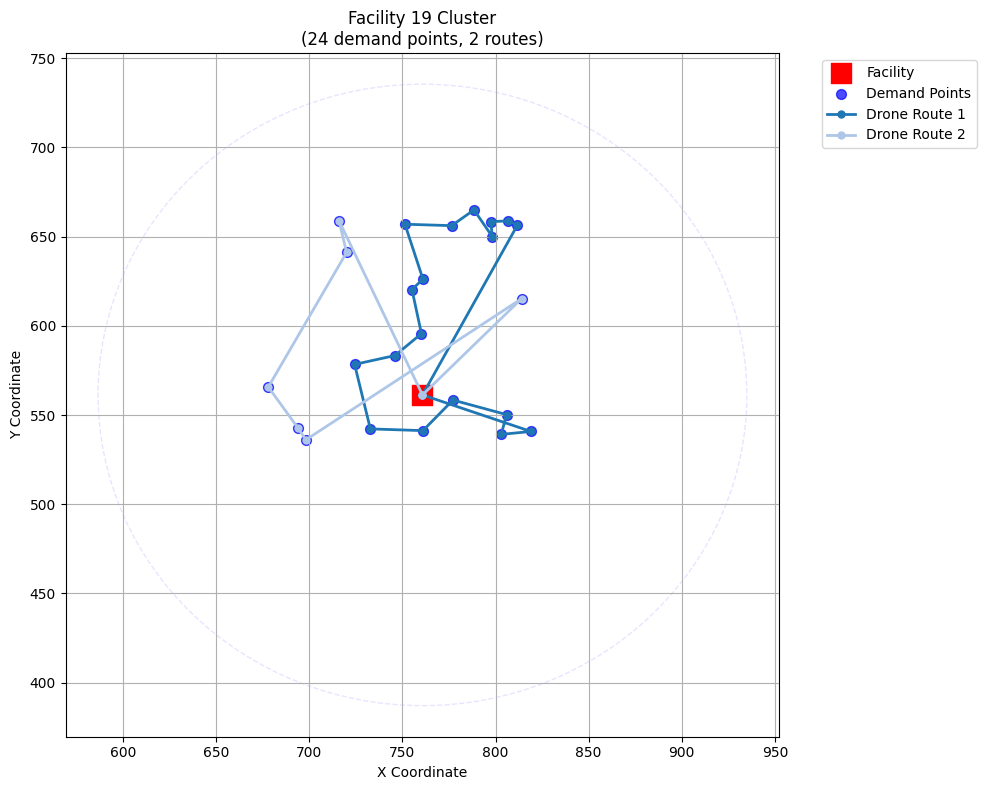

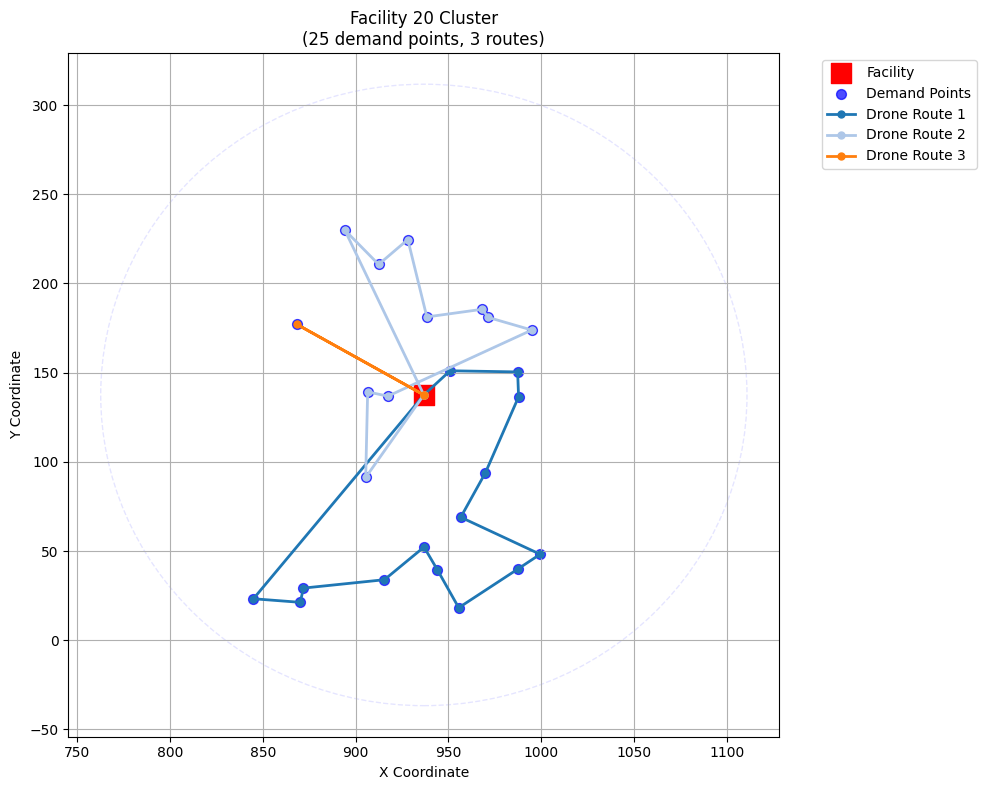

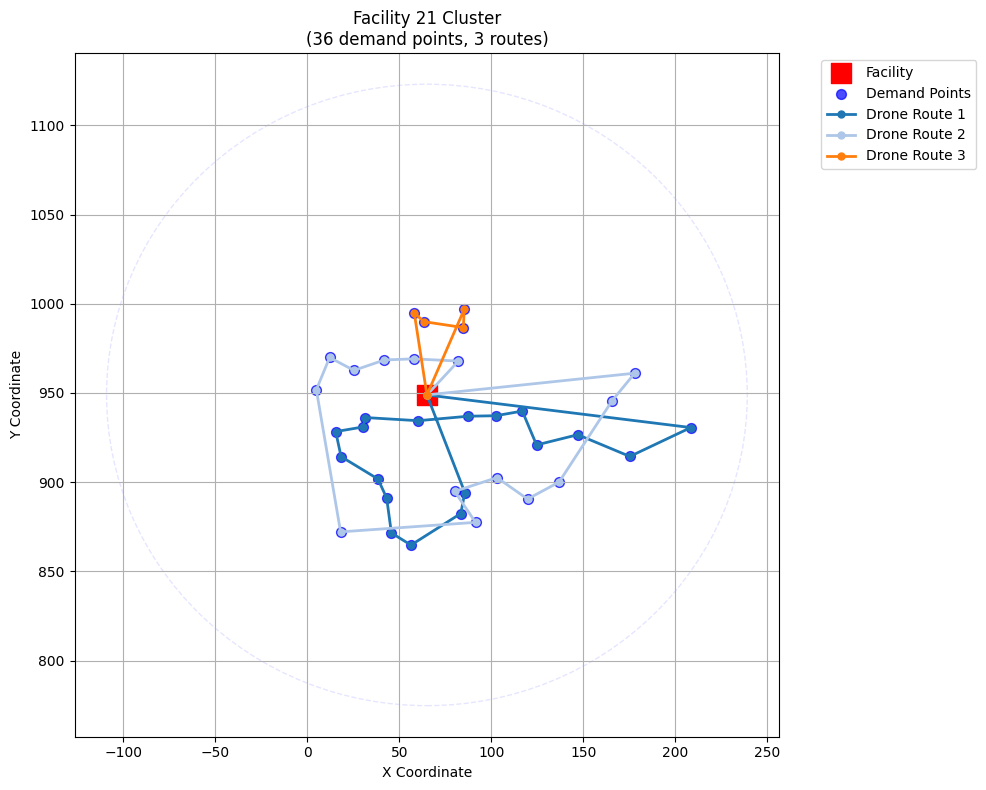

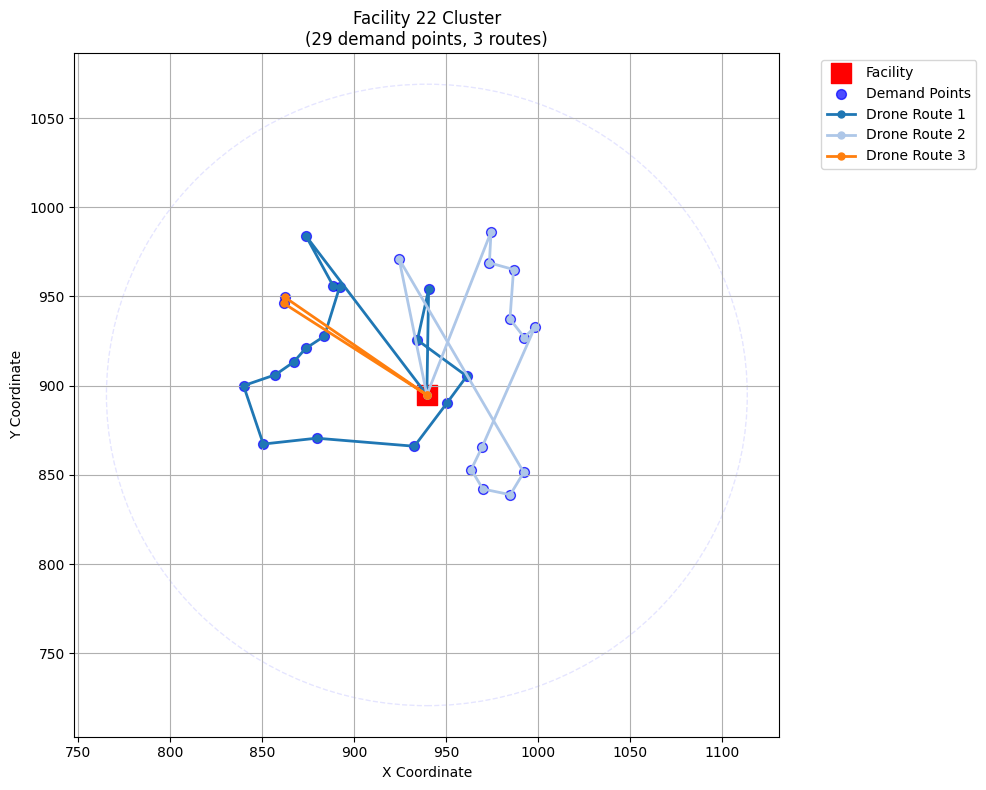

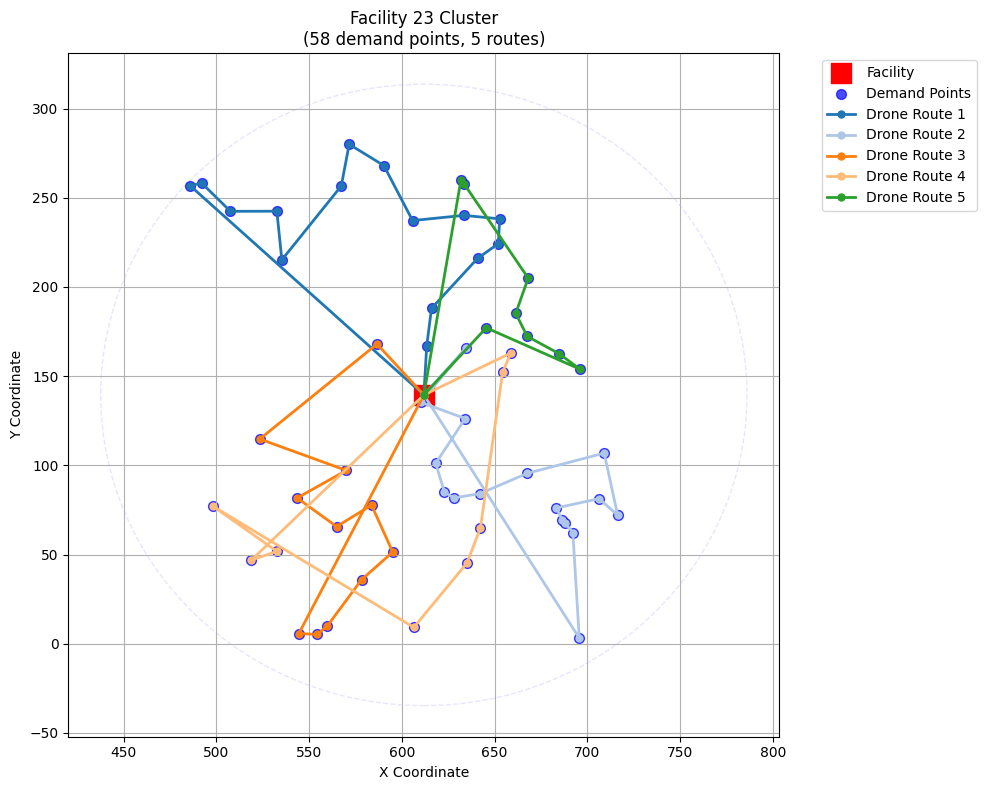

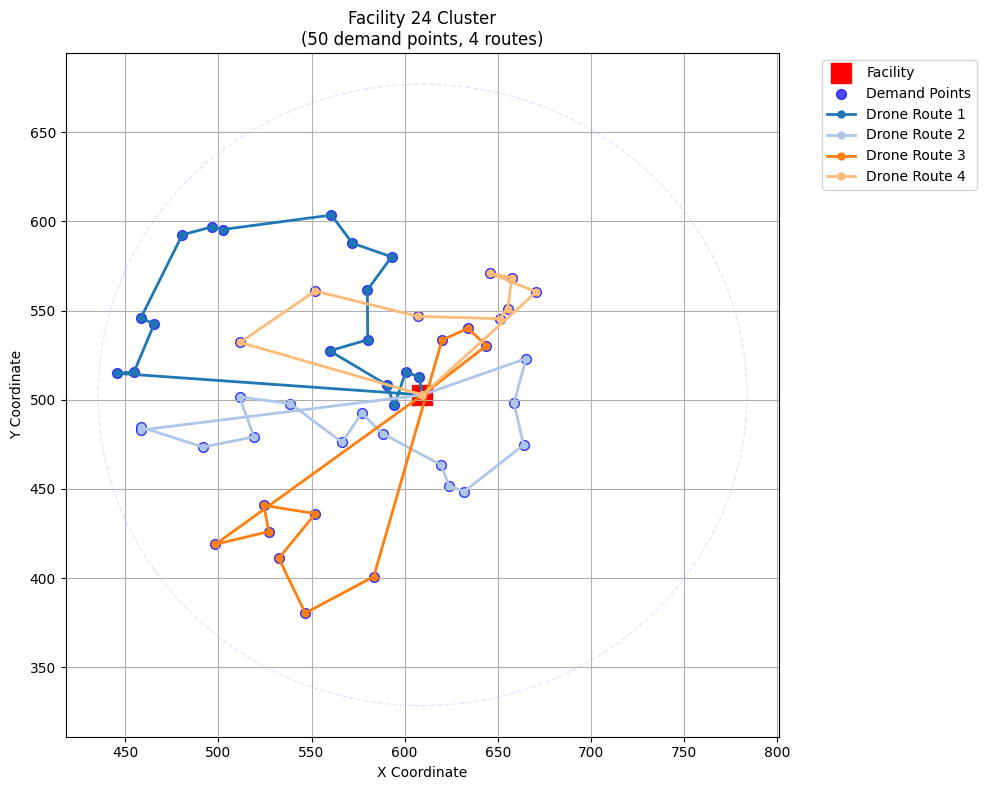

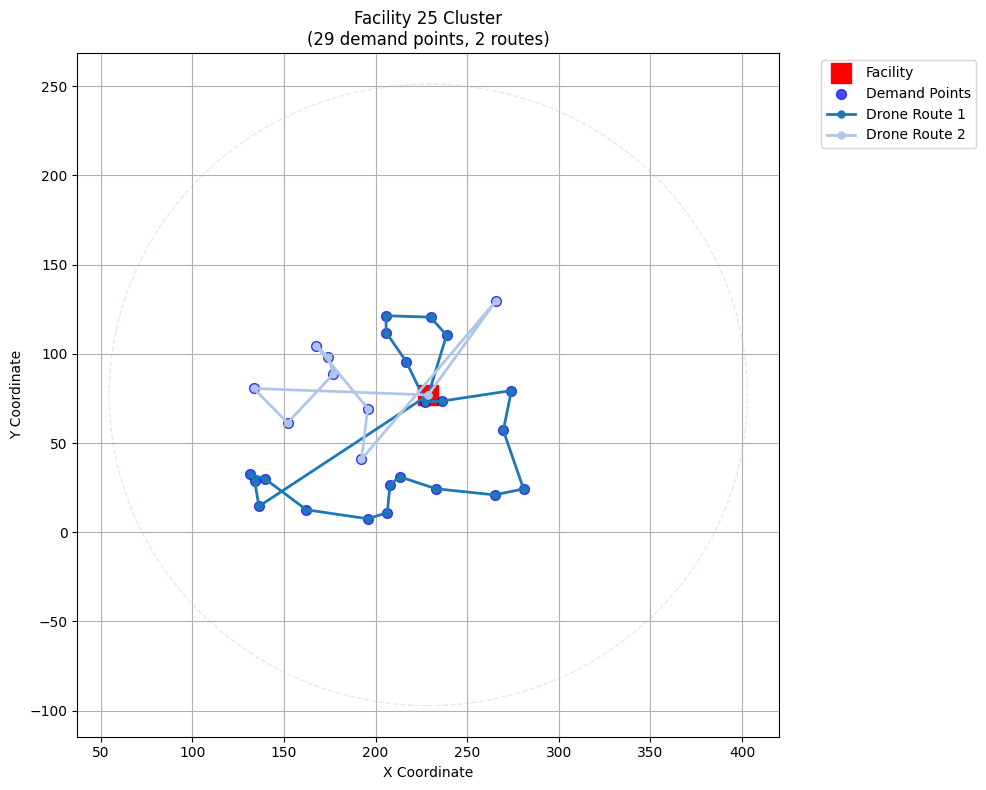

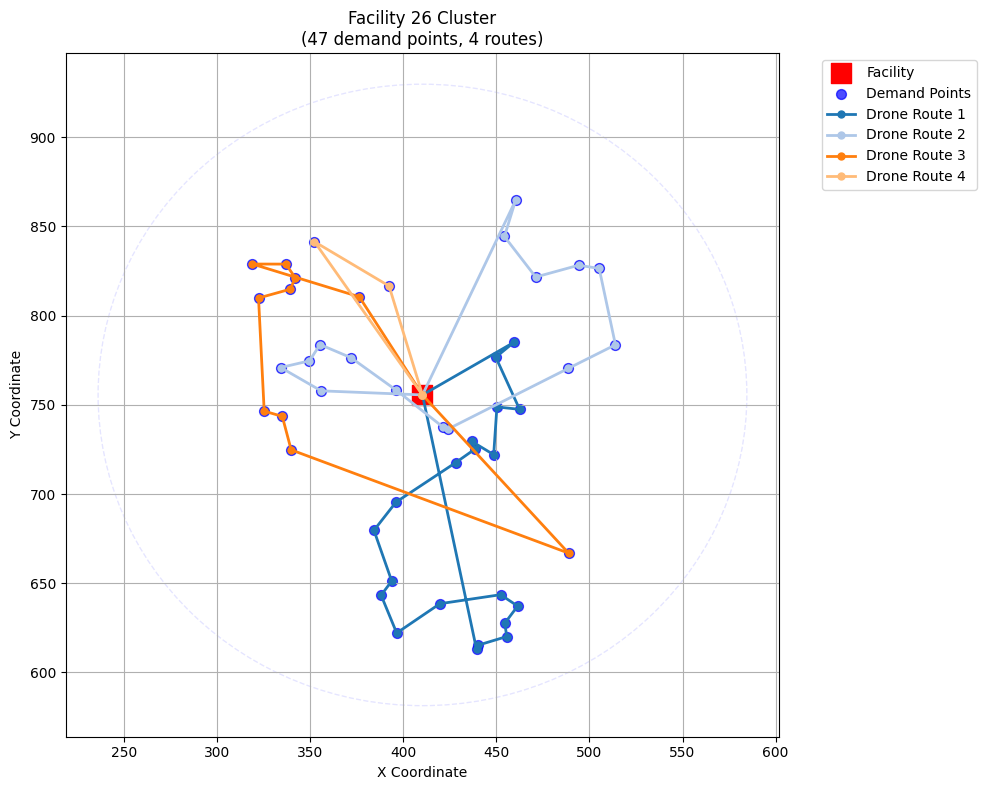

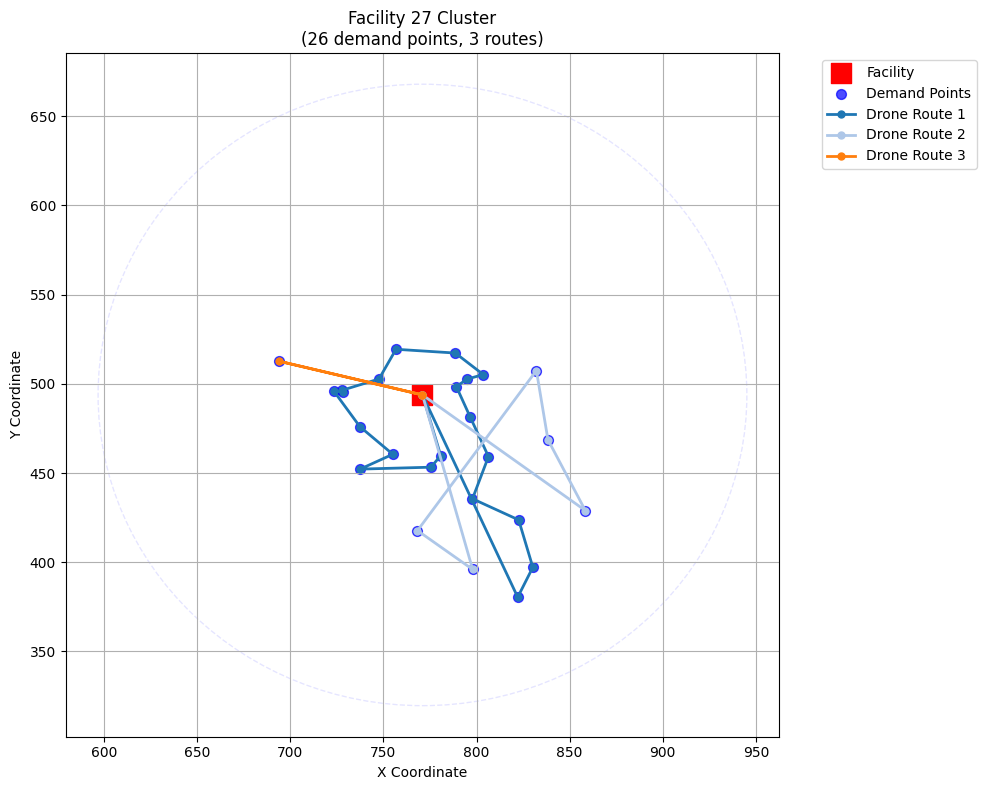

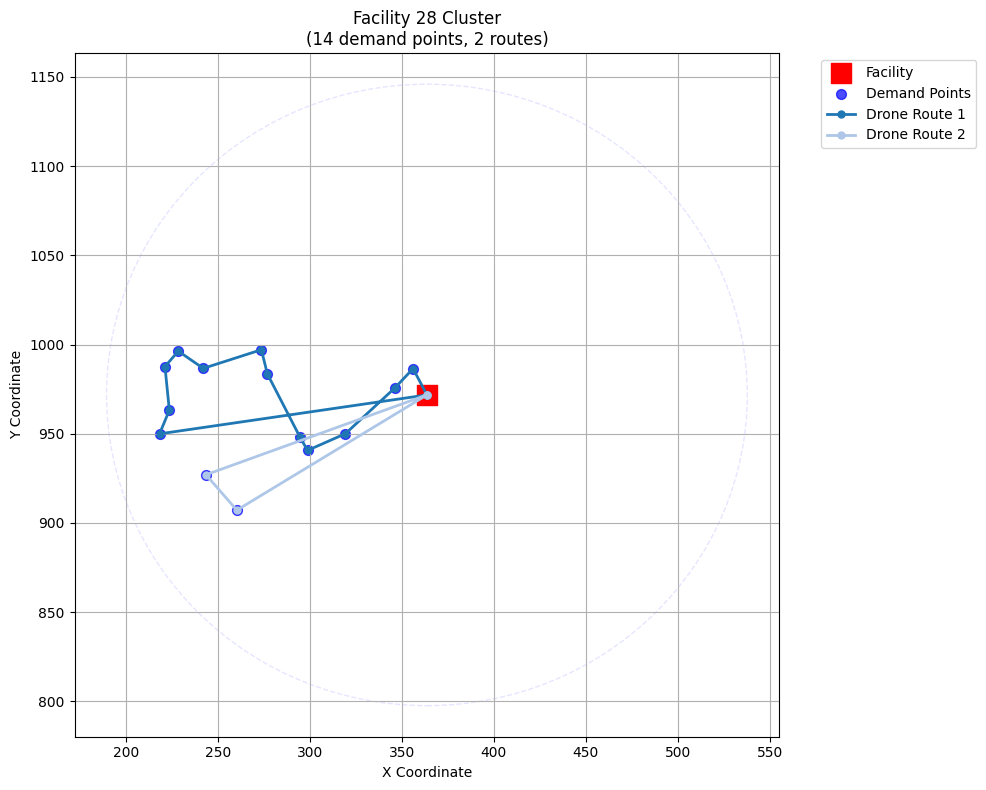

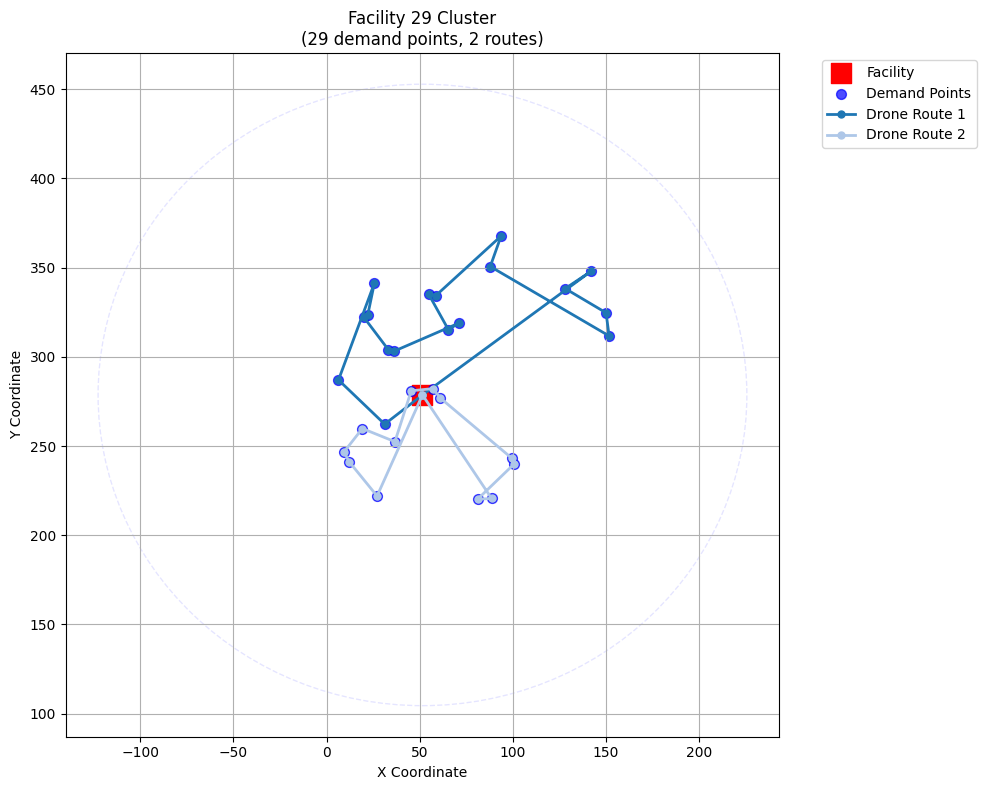

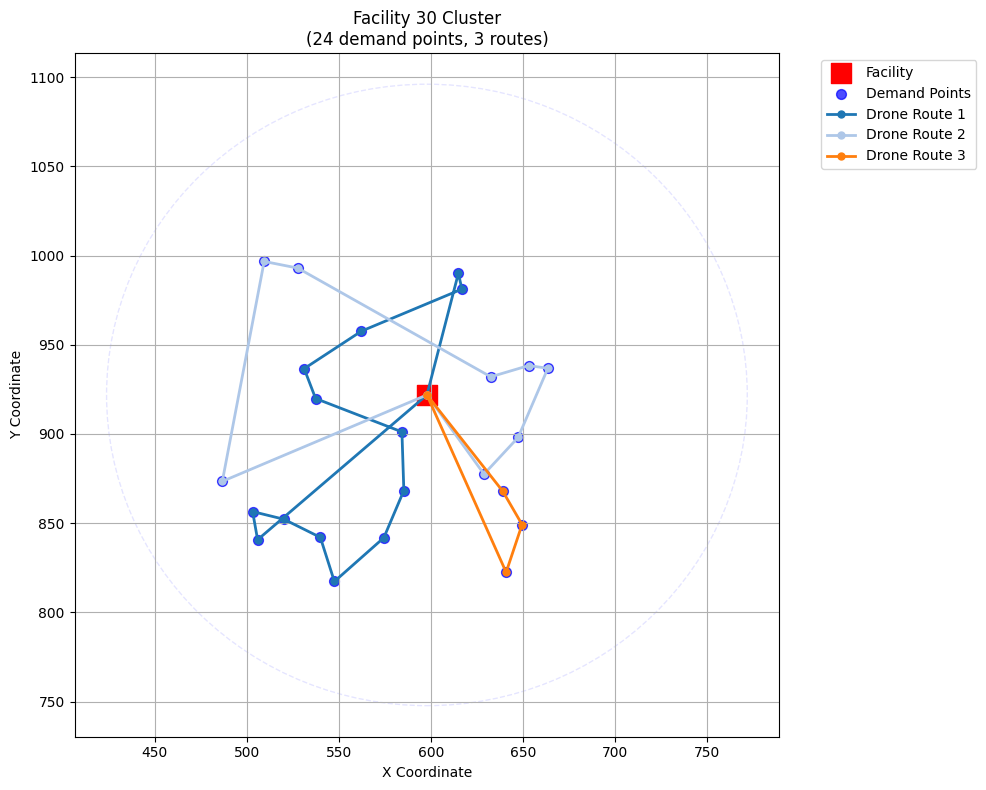


Optimization complete!


In [14]:
import numpy as np
import math
from typing import List, Tuple, Dict, Set
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import random

class UAVPathOptimizer:
    """
    UAV Path Optimizer with B/3 strategy and enhanced visualization
    """
    
    def __init__(self, facilities, demand_points, B, battery_buffer=0.9):
        self.facilities = facilities
        self.demand_points = demand_points
        self.B = B
        self.R = (B * battery_buffer) / 3
        self.clusters = self._cluster_demand_points()
        self.colors = plt.cm.tab20.colors  # Color palette for visualization

    def _distance(self, p1, p2):
        return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

    def _cluster_demand_points(self):
        """Assign demand points to nearest facility within B/3 radius"""
        clusters = {fac: [] for fac in self.facilities}
        for point in self.demand_points:
            nearest_fac = min(self.facilities, key=lambda f: self._distance(f, point))
            if self._distance(nearest_fac, point) <= self.R:
                clusters[nearest_fac].append(point)
        return clusters

    def optimize_routes(self):
        """Generate optimized routes with B/3 constraints"""
        routes = {}
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            unserved = set(points)
            facility_routes = []
            
            while unserved:
                route = [fac]
                remaining_battery = self.B
                
                # Furthest-first initialization
                if not unserved:
                    break
                farthest = max(unserved, key=lambda p: self._distance(fac, p))
                dist = self._distance(fac, farthest)
                
                if dist > remaining_battery / 2:
                    break  # Can't reach and return
                
                route.append(farthest)
                unserved.remove(farthest)
                remaining_battery -= dist
                
                # Nearest-neighbor greedy addition
                while unserved and remaining_battery > 0:
                    current_pos = route[-1]
                    next_point = None
                    min_dist = float('inf')
                    
                    for p in unserved:
                        dist = self._distance(current_pos, p)
                        return_dist = self._distance(p, fac)
                        if dist + return_dist <= remaining_battery and dist < min_dist:
                            min_dist = dist
                            next_point = p
                            
                    if next_point is None:
                        break
                        
                    route.append(next_point)
                    unserved.remove(next_point)
                    remaining_battery -= min_dist
                
                # Return to facility
                route.append(fac)
                facility_routes.append(route)
            
            routes[fac] = facility_routes
            
        return routes

    def visualize_clusters(self):
        """Visualize facility clusters with service radius"""
        plt.figure(figsize=(12, 10))
        
        # Plot all demand points (gray)
        all_x, all_y = zip(*self.demand_points)
        plt.scatter(all_x, all_y, c='lightgray', s=20, alpha=0.5, label='Unserved Demand')
        
        # Plot facilities and their clusters
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            fac_x, fac_y = fac
            
            # Draw service radius
            circle = plt.Circle(fac, self.R, color=self.colors[fac_idx % 20], 
                              alpha=0.1, linestyle='--', fill=False)
            plt.gca().add_patch(circle)
            
            # Plot facility
            plt.scatter(fac_x, fac_y, c=[self.colors[fac_idx % 20]], 
                       s=200, marker='s', edgecolor='k', label=f'Facility {fac_idx+1}')
            
            # Plot served points
            if points:
                cluster_x, cluster_y = zip(*points)
                plt.scatter(cluster_x, cluster_y, c=[self.colors[fac_idx % 20]], 
                           s=50, alpha=0.7)
        
        plt.title(f"Facility Clusters with B/3 Service Radius (R = {self.R:.1f})")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def visualize_all_routes(self, routes):
        """Static visualization of all routes"""
        plt.figure(figsize=(14, 12))
        
        # Plot facilities
        fac_x, fac_y = zip(*self.facilities)
        plt.scatter(fac_x, fac_y, c='red', s=200, marker='s', edgecolor='k', label='Facilities')
        
        # Plot demand points
        for fac_idx, (fac, points) in enumerate(self.clusters.items()):
            if points:
                x, y = zip(*points)
                plt.scatter(x, y, c=[self.colors[fac_idx % 20]], s=30, alpha=0.7)
        
        # Plot routes
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            for route in fac_routes:
                x, y = zip(*route)
                plt.plot(x, y, 'o-', c=self.colors[fac_idx % 20], 
                        alpha=0.5, lw=1.5, ms=4)
        
        plt.title(f"Complete UAV Path Optimization\nTotal Battery: {self.B}, Service Radius: {self.R:.1f}")
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_individual_facility_clusters(self, routes):
        """Generate separate cluster plots for each facility showing its routes"""
        for fac_idx, (fac, fac_routes) in enumerate(routes.items()):
            plt.figure(figsize=(10, 8))
            
            # Plot facility
            plt.scatter(fac[0], fac[1], c='red', s=200, marker='s', label='Facility')
            
            # Draw service radius
            circle = plt.Circle(fac, self.R, color='blue', alpha=0.1, linestyle='--', fill=False)
            plt.gca().add_patch(circle)
            
            # Plot all demand points in this cluster
            cluster_points = self.clusters[fac]
            if cluster_points:
                cluster_x, cluster_y = zip(*cluster_points)
                plt.scatter(cluster_x, cluster_y, c='blue', s=50, alpha=0.7, label='Demand Points')
            
            # Plot routes with different colors
            for route_idx, route in enumerate(fac_routes):
                route_x, route_y = zip(*route)
                plt.plot(route_x, route_y, 'o-', 
                         color=self.colors[route_idx % 20],
                         linewidth=2,
                         markersize=5,
                         label=f'Drone Route {route_idx+1}')
            
            plt.title(f'Facility {fac_idx+1} Cluster\n({len(cluster_points)} demand points, {len(fac_routes)} routes)')
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    import numpy as np
    
    # ======================
    # USER-CONFIGURABLE PARAMETERS
    # ======================
    # Edit these values directly in the script before running
    
    # Problem Parameters
    p = 30                # Maximum number of facilities to open (integer)
    K = 100               # Total drones available (integer)
    U = 500.0            # Facility capacity (float)
    B = 550.0            # Drone battery capacity (float)
    battery_buffer = 0.95 # Battery safety margin (0-1, float)
    
    # Data Generation Parameters
    num_facility_locations = 100  # Potential locations to choose from (integer)
    num_demand_points = 1000      # Total demand points (integer)
    random_seed = 42             # For reproducible results (integer)
    area_size = 1000.0            # Size of operational area in km (float)
    
    # Visualization Options
    show_cluster_plot = True     # Show facility clusters visualization
    show_route_plot = True       # Show complete routes visualization
    show_individual_clusters = True # Show individual facility clusters
    
    # ======================
    # DATA GENERATION
    # ======================
    np.random.seed(random_seed)
    
    print("Generating problem instance...")
    facility_locations = [(np.random.uniform(0, area_size), 
                         np.random.uniform(0, area_size)) 
                         for _ in range(num_facility_locations)]
    
    demand_points = [(np.random.uniform(0, area_size), 
                    np.random.uniform(0, area_size)) 
                    for _ in range(num_demand_points)]
    
    # Calculate distances (battery consumption)
    def euclidean_distance(a, b):
        return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    
    # ======================
    # FACILITY SELECTION
    # ======================
    print("Selecting optimal facility locations...")
    kmeans = KMeans(n_clusters=p, random_state=random_seed)
    coords = np.array(demand_points)
    kmeans.fit(coords)
    
    selected_facilities = []
    for center in kmeans.cluster_centers_:
        nearest_fac = min(facility_locations, 
                         key=lambda f: euclidean_distance(f, tuple(center)))
        selected_facilities.append(nearest_fac)
    
    # ======================
    # RUN OPTIMIZATION
    # ======================
    print("Running UAV path optimization...")
    optimizer = UAVPathOptimizer(
        facilities=selected_facilities,
        demand_points=demand_points,
        B=B,
        battery_buffer=battery_buffer
    )
    
    routes = optimizer.optimize_routes()
    
    # ======================
    # RESULTS
    # ======================
    print("\nOptimization Results:")
    print("====================")
    
    total_routes = sum(len(r) for r in routes.values())
    served = sum(len(route)-2 for fac_routes in routes.values() for route in fac_routes)
    
    print(f"Facilities opened: {len(selected_facilities)}/{p}")
    print(f"Total demand points: {num_demand_points}")
    print(f"Demand points served: {served} ({served/num_demand_points:.1%})")
    print(f"Total routes generated: {total_routes}")
    print(f"Drone utilization: {total_routes}/{K} ({total_routes/K:.1%})")
    print(f"Average points per route: {served/total_routes:.1f}")
    
    # ======================
    # VISUALIZATION
    # ======================
    if show_cluster_plot:
        print("\nDisplaying facility clusters...")
        optimizer.visualize_clusters()
    
    if show_route_plot:
        print("\nDisplaying complete route visualization...")
        optimizer.visualize_all_routes(routes)
    
    if show_individual_clusters:
        print("\nDisplaying individual facility clusters...")
        optimizer.plot_individual_facility_clusters(routes)
    
    print("\nOptimization complete!")